# Door Condition Monitoring
## Fault Analysis — Normal vs Abnormal Resistance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

In [2]:
DATA_DIR = Path("../PS3/02_Datasets/Door")

TRAIN_PATH = DATA_DIR / "Train.csv"
SEGMENTS_PATH = Path("segmented_training_cycles.csv")

print("Train exists:", TRAIN_PATH.exists())
print("Segments exist:", SEGMENTS_PATH.exists())

Train exists: True
Segments exist: True


In [3]:
train = pd.read_csv(TRAIN_PATH)
segments = pd.read_csv(SEGMENTS_PATH)

print("Train shape:", train.shape)
print("Segments shape:", segments.shape)

display(segments.head())

Train shape: (18036, 17)
Segments shape: (110, 9)


,start_idx,end_idx,n_rows,start_timestamp,end_timestamp,segment_id,operation,status,duration_seconds
0,0,185,186,2023-07-05 00:00:00.000,2023-07-05 00:00:03.700,train_seg_001,Close,Normal,3.70
1,186,328,143,2023-07-05 00:00:23.999,2023-07-05 00:00:26.839,train_seg_002,Open,Normal,2.84
2,329,465,137,2023-07-05 00:00:51.266,2023-07-05 00:00:53.986,train_seg_003,Open,Abnormal resistance,2.72
3,466,652,187,2023-07-05 00:01:33.989,2023-07-05 00:01:37.709,train_seg_004,Close,Abnormal resistance,3.72
4,653,838,186,2023-07-05 00:02:24.608,2023-07-05 00:02:28.308,train_seg_005,Close,Abnormal resistance,3.70


In [4]:
# Convert the custom Door timestamp format into Pandas timestamps.


def parse_door_datetime(value):
    parts = str(value).split("-")

    if len(parts) != 7:
        return pd.NaT

    try:
        year, month, day, hour, minute, second, ms = map(int, parts)

        return pd.Timestamp(year=year, month=month, day=day, hour=hour, minute=minute, second=second, microsecond=ms * 1000)

    except (ValueError, TypeError):
        return pd.NaT

In [5]:
# Parse timestamps so that we can analyse individual cycles in time.

train["timestamp"] = train["Datetime"].apply(parse_door_datetime)

print("Invalid timestamps:", train["timestamp"].isna().sum())

Invalid timestamps: 0


In [6]:
# Check how many Normal and Abnormal cycles exist for each operation type.

display(pd.crosstab(segments["operation"], segments["status"], margins=True))

status,Abnormal resistance,Normal,All
operation,,,
Close,15,40,55
Open,15,40,55
All,30,80,110


In [7]:
# Display every cycle so we can refer to specific segment IDs during analysis.

display(segments[["segment_id", "operation", "status", "start_timestamp", "end_timestamp", "duration_seconds", "n_rows"]])

,segment_id,operation,status,start_timestamp,end_timestamp,duration_seconds,n_rows
0,train_seg_001,Close,Normal,2023-07-05 00:00:00.000,2023-07-05 00:00:03.700,3.70,186
1,train_seg_002,Open,Normal,2023-07-05 00:00:23.999,2023-07-05 00:00:26.839,2.84,143
2,train_seg_003,Open,Abnormal resistance,2023-07-05 00:00:51.266,2023-07-05 00:00:53.986,2.72,137
3,train_seg_004,Close,Abnormal resistance,2023-07-05 00:01:33.989,2023-07-05 00:01:37.709,3.72,187
4,train_seg_005,Close,Abnormal resistance,2023-07-05 00:02:24.608,2023-07-05 00:02:28.308,3.70,186
...,...,...,...,...,...,...,...
105,train_seg_106,Close,Normal,2023-07-05 01:06:57.185,2023-07-05 01:07:00.785,3.60,181
106,train_seg_107,Open,Normal,2023-07-05 01:07:23.681,2023-07-05 01:07:26.521,2.84,143
107,train_seg_108,Open,Abnormal resistance,2023-07-05 01:08:24.815,2023-07-05 01:08:27.635,2.82,142
108,train_seg_109,Close,Normal,2023-07-05 01:09:25.783,2023-07-05 01:09:29.483,3.70,186


In [8]:
# Extract the raw sensor readings belonging to one segmented door operation.


def extract_cycle(train_df, segment_row):
    start_idx = int(segment_row["start_idx"])
    end_idx = int(segment_row["end_idx"])

    return train_df.loc[start_idx:end_idx].copy()

In [9]:
# one labelled cycle in detail.

example_segment = segments.iloc[0]

example_cycle = extract_cycle(train, example_segment)

print("Segment ID:", example_segment["segment_id"])
print("Operation:", example_segment["operation"])
print("Status:", example_segment["status"])
print("Rows:", len(example_cycle))
print("Duration:", example_segment["duration_seconds"], "seconds")

display(example_cycle.head())

Segment ID: train_seg_001
Operation: Close
Status: Normal
Rows: 186
Duration: 3.7 seconds


,Datetime,Motor current(mA),Motor Voltage(10mV),Motor electrodynamic force,Door opening time(.1s),Door closing time(.1s),Close command,Open command,DCSR,DCSL,DLSR,DLSL,Door Opened,Door Locked,Door is opening,Door is closing,Door leaf position,timestamp
0,2023-7-5-0-0-0-0,115,400,53,24,35,1,0,0,0,0,0,0,0,0,1,700,2023-07-05 00:00:00.000
1,2023-7-5-0-0-0-20,132,600,93,24,35,1,0,0,0,0,0,0,0,0,1,700,2023-07-05 00:00:00.020
2,2023-7-5-0-0-0-40,176,700,108,24,35,1,0,0,0,0,0,0,0,0,1,700,2023-07-05 00:00:00.040
3,2023-7-5-0-0-0-60,317,1000,114,24,35,1,0,0,0,0,0,0,0,0,1,699,2023-07-05 00:00:00.060
4,2023-7-5-0-0-0-80,503,1500,150,24,35,1,0,0,0,0,0,0,0,0,1,699,2023-07-05 00:00:00.080


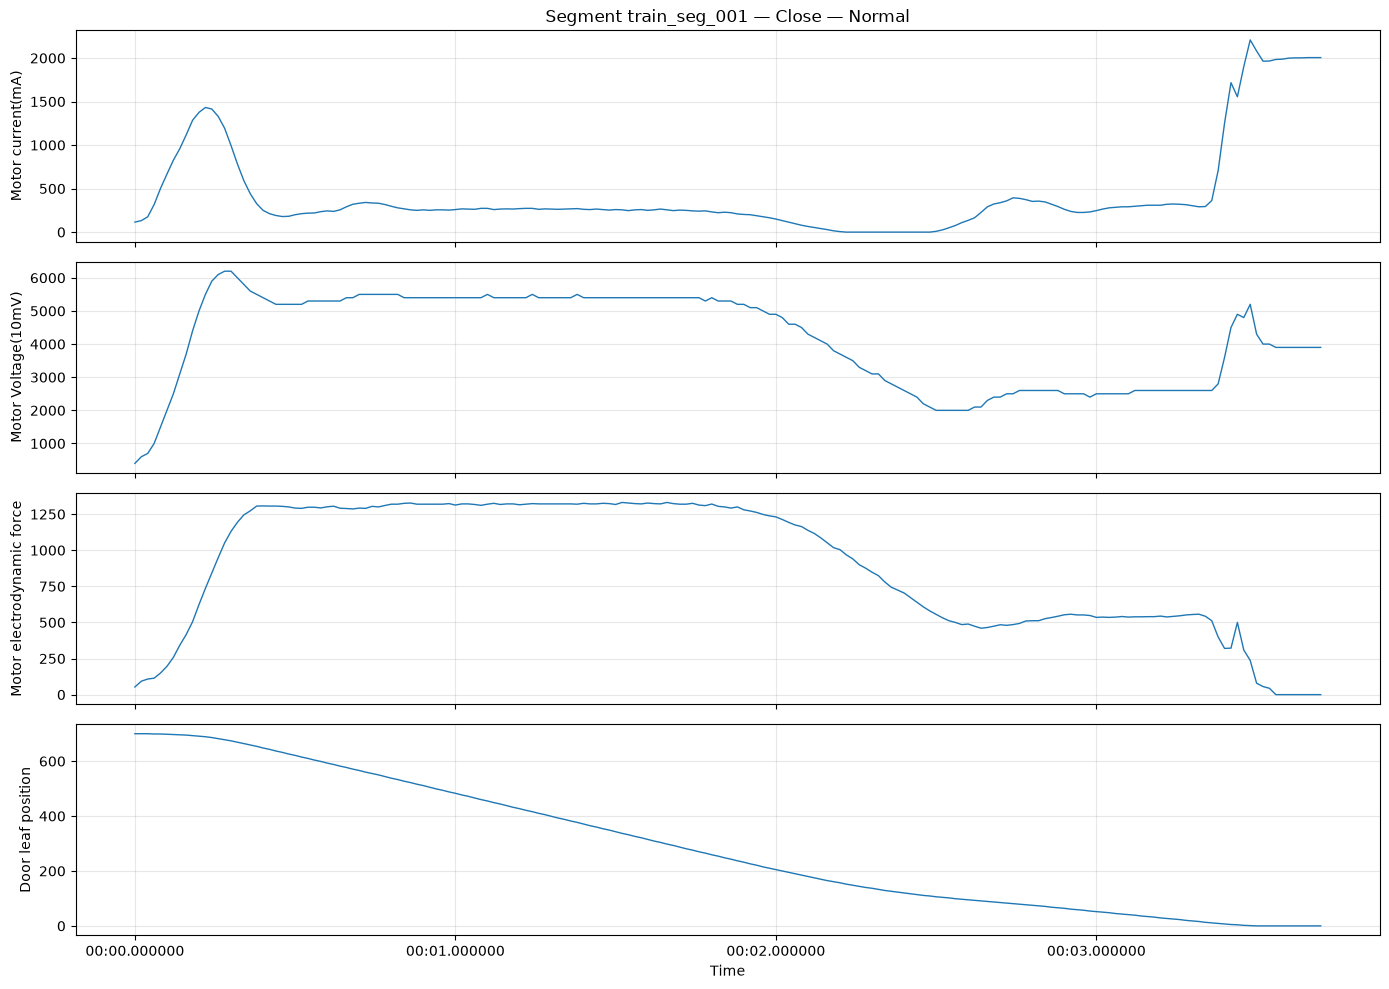

In [10]:
# Plot the main electrical and mechanical signals for one complete cycle.

signals = ["Motor current(mA)", "Motor Voltage(10mV)", "Motor electrodynamic force", "Door leaf position"]

fig, axes = plt.subplots(len(signals), 1, figsize=(14, 10), sharex=True)

for ax, signal in zip(axes, signals):
    ax.plot(example_cycle["timestamp"], example_cycle[signal], linewidth=1)

    ax.set_ylabel(signal)
    ax.grid(alpha=0.3)

axes[0].set_title(f"Segment {example_segment['segment_id']} — {example_segment['operation']} — {example_segment['status']}")

axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

## Normal vs Abnormal Resistance

In [11]:
# Separate the cycles into the four analysis groups.

normal_open = segments[(segments["operation"] == "Open") & (segments["status"] == "Normal")]
abnormal_open = segments[(segments["operation"] == "Open") & (segments["status"] == "Abnormal resistance")]
normal_close = segments[(segments["operation"] == "Close") & (segments["status"] == "Normal")]
abnormal_close = segments[(segments["operation"] == "Close") & (segments["status"] == "Abnormal resistance")]

print("Normal Open:", len(normal_open))
print("Abnormal Open:", len(abnormal_open))
print("Normal Close:", len(normal_close))
print("Abnormal Close:", len(abnormal_close))

Normal Open: 40
Abnormal Open: 15
Normal Close: 40
Abnormal Close: 15


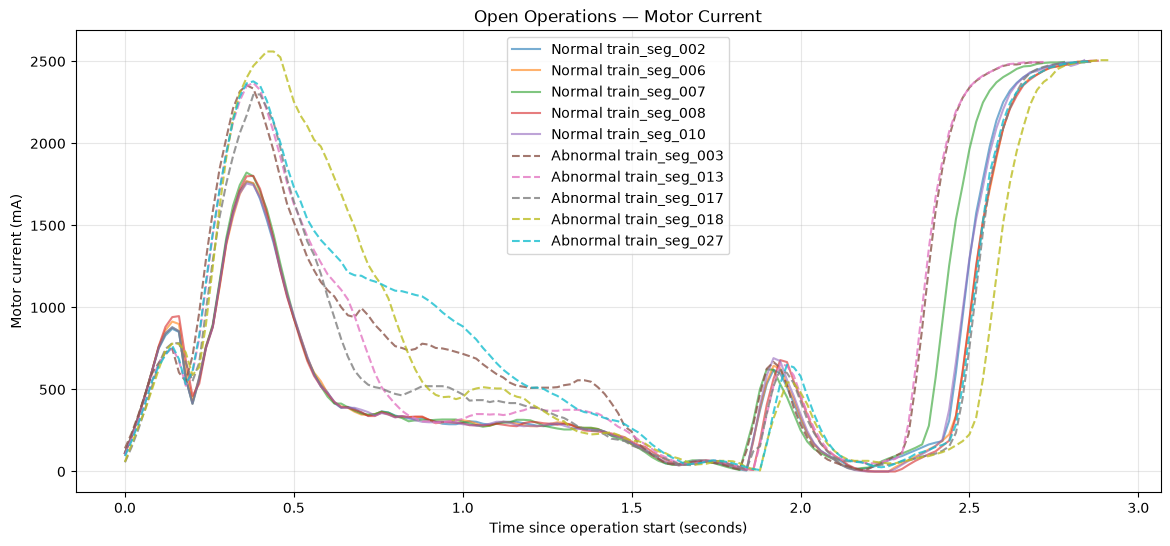

In [12]:
# Compare a few Open cycles using their original time scale.

plt.figure(figsize=(14, 6))

for _, segment in normal_open.head(5).iterrows():
    cycle = extract_cycle(train, segment)

    relative_time = (cycle["timestamp"] - cycle["timestamp"].iloc[0]).dt.total_seconds()

    plt.plot(relative_time, cycle["Motor current(mA)"], alpha=0.6, label=f"Normal {segment['segment_id']}")

for _, segment in abnormal_open.head(5).iterrows():
    cycle = extract_cycle(train, segment)

    relative_time = (cycle["timestamp"] - cycle["timestamp"].iloc[0]).dt.total_seconds()

    plt.plot(relative_time, cycle["Motor current(mA)"], linestyle="--", alpha=0.8, label=f"Abnormal {segment['segment_id']}")

plt.xlabel("Time since operation start (seconds)")
plt.ylabel("Motor current (mA)")
plt.title("Open Operations — Motor Current")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

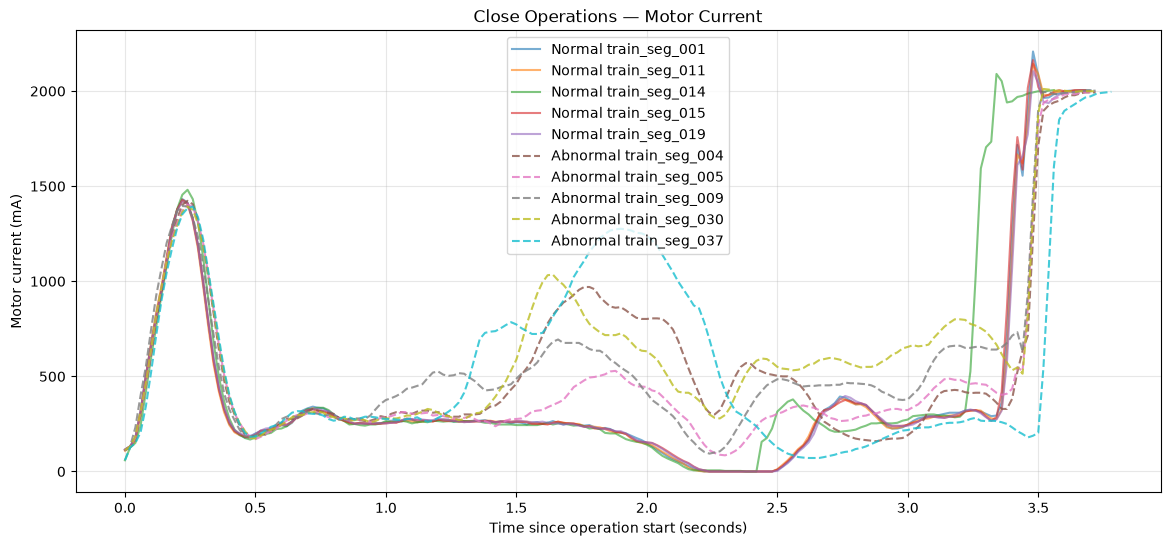

In [13]:
# Compare a few Close cycles using their original time scale.

plt.figure(figsize=(14, 6))

for _, segment in normal_close.head(5).iterrows():
    cycle = extract_cycle(train, segment)

    relative_time = (cycle["timestamp"] - cycle["timestamp"].iloc[0]).dt.total_seconds()

    plt.plot(relative_time, cycle["Motor current(mA)"], alpha=0.6, label=f"Normal {segment['segment_id']}")

for _, segment in abnormal_close.head(5).iterrows():
    cycle = extract_cycle(train, segment)

    relative_time = (cycle["timestamp"] - cycle["timestamp"].iloc[0]).dt.total_seconds()

    plt.plot(relative_time, cycle["Motor current(mA)"], linestyle="--", alpha=0.8, label=f"Abnormal {segment['segment_id']}")

plt.xlabel("Time since operation start (seconds)")
plt.ylabel("Motor current (mA)")
plt.title("Close Operations — Motor Current")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [14]:
# Resample a cycle onto a common 0–100% operation-progress axis.


def normalise_cycle(cycle, signals, n_points=100):
    x_old = np.linspace(0, 1, len(cycle))

    x_new = np.linspace(0, 1, n_points)

    result = pd.DataFrame({"progress": x_new})

    for signal in signals:
        values = pd.to_numeric(cycle[signal], errors="coerce").to_numpy()
        result[signal] = np.interp(x_new, x_old, values)

    return result

In [16]:
# Test the normalisation function on one cycle.

normalised_example = normalise_cycle(example_cycle, signals)

print("Original rows:", len(example_cycle))
print("Normalised rows:", len(normalised_example))

display(normalised_example.head())

Original rows: 186
Normalised rows: 100


,progress,Motor current(mA),Motor Voltage(10mV),Motor electrodynamic force,Door leaf position
0,0.000000,115.000000,400.000000,53.000000,700.000000
1,0.010101,170.222222,686.868687,106.030303,700.000000
2,0.020202,454.151515,1368.686869,140.545455,699.000000
3,0.030303,763.363636,2303.030303,233.575758,697.393939
4,0.040404,1033.484848,3384.848485,377.131313,695.525253


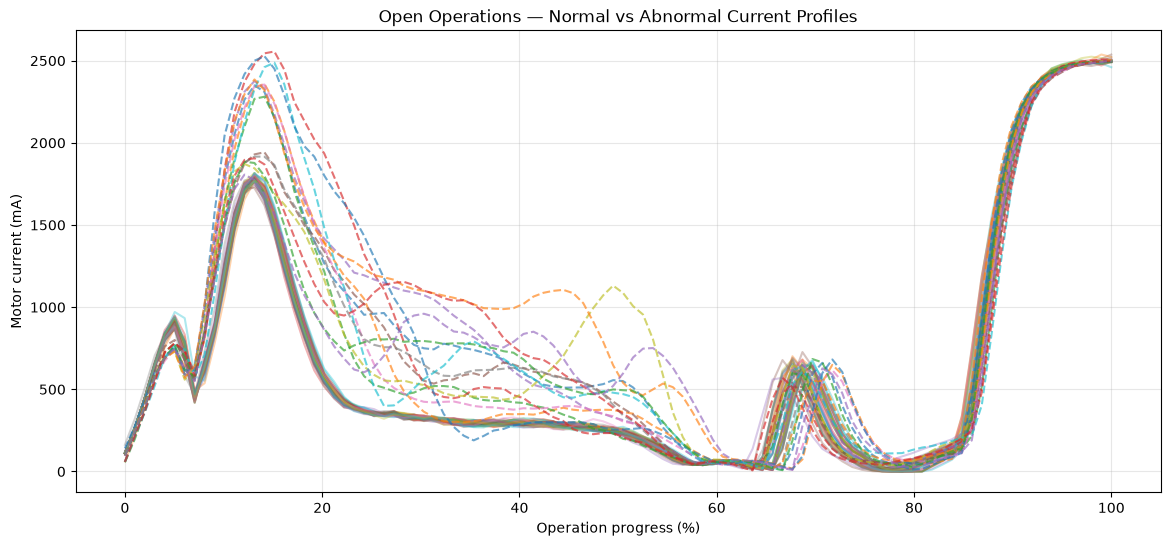

In [17]:
# Compare Open cycles after aligning them to a common 0–100% progress scale.

plt.figure(figsize=(14, 6))

for _, segment in normal_open.iterrows():
    cycle = extract_cycle(train, segment)

    normalised = normalise_cycle(cycle, ["Motor current(mA)"])

    plt.plot(normalised["progress"] * 100, normalised["Motor current(mA)"], alpha=0.35)

for _, segment in abnormal_open.iterrows():
    cycle = extract_cycle(train, segment)

    normalised = normalise_cycle(cycle, ["Motor current(mA)"])

    plt.plot(normalised["progress"] * 100, normalised["Motor current(mA)"], linestyle="--", alpha=0.65)

plt.xlabel("Operation progress (%)")
plt.ylabel("Motor current (mA)")
plt.title("Open Operations — Normal vs Abnormal Current Profiles")

plt.grid(alpha=0.3)
plt.show()

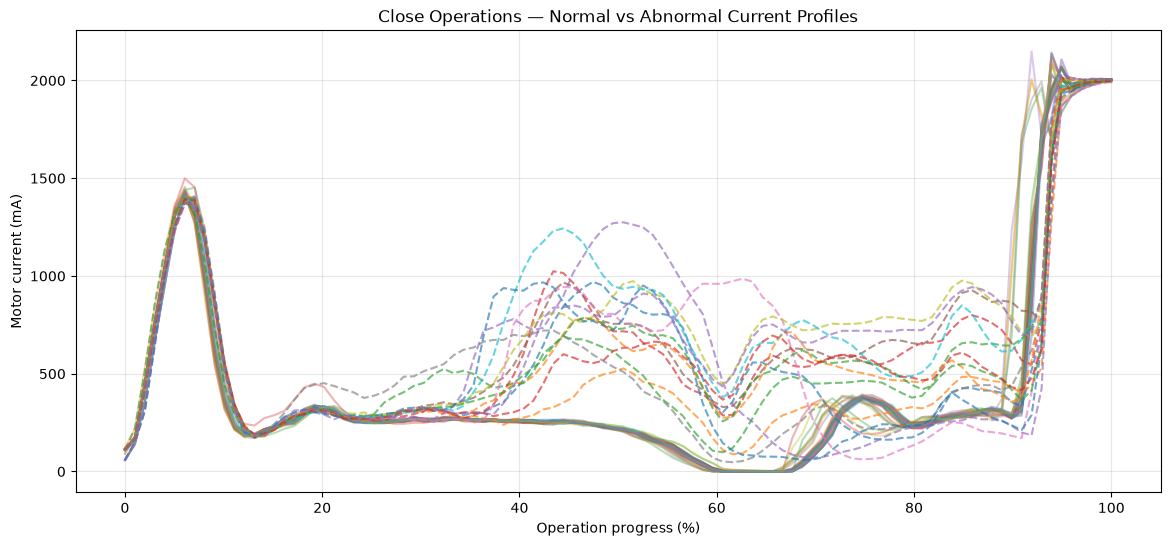

In [18]:
# Compare Close cycles after aligning them to a common 0–100% progress scale.

plt.figure(figsize=(14, 6))

for _, segment in normal_close.iterrows():
    cycle = extract_cycle(train, segment)

    normalised = normalise_cycle(cycle, ["Motor current(mA)"])

    plt.plot(normalised["progress"] * 100, normalised["Motor current(mA)"], alpha=0.35)

for _, segment in abnormal_close.iterrows():
    cycle = extract_cycle(train, segment)

    normalised = normalise_cycle(cycle, ["Motor current(mA)"])

    plt.plot(normalised["progress"] * 100, normalised["Motor current(mA)"], linestyle="--", alpha=0.65)

plt.xlabel("Operation progress (%)")
plt.ylabel("Motor current (mA)")
plt.title("Close Operations — Normal vs Abnormal Current Profiles")

plt.grid(alpha=0.3)
plt.show()

In [19]:
# Convert a group of cycles into a matrix of normalised signal profiles.


def build_profiles(segments_df, signal, n_points=100):
    profiles = []

    for _, segment in segments_df.iterrows():
        cycle = extract_cycle(train, segment)

        normalised = normalise_cycle(cycle, [signal], n_points=n_points)

        profiles.append(normalised[signal].to_numpy())

    return np.array(profiles)

In [20]:
# Build Normal and Abnormal Open motor-current profiles.

normal_open_current = build_profiles(normal_open, "Motor current(mA)")

abnormal_open_current = build_profiles(abnormal_open, "Motor current(mA)")

print("Normal Open matrix:", normal_open_current.shape)

print("Abnormal Open matrix:", abnormal_open_current.shape)

Normal Open matrix: (40, 100)
Abnormal Open matrix: (15, 100)


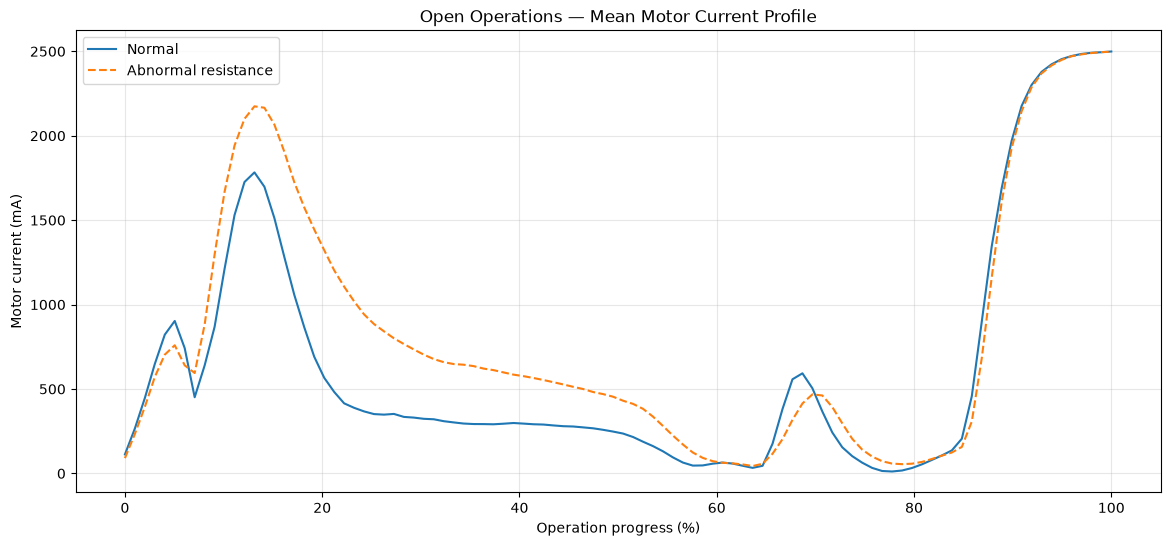

In [21]:
# Compare the mean motor-current trajectory for Normal and Abnormal Open cycles.

x = np.linspace(0, 100, 100)

normal_mean = normal_open_current.mean(axis=0)
abnormal_mean = abnormal_open_current.mean(axis=0)

plt.figure(figsize=(14, 6))

plt.plot(x, normal_mean, label="Normal")
plt.plot(x, abnormal_mean, linestyle="--", label="Abnormal resistance")

plt.xlabel("Operation progress (%)")
plt.ylabel("Motor current (mA)")
plt.title("Open Operations — Mean Motor Current Profile")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

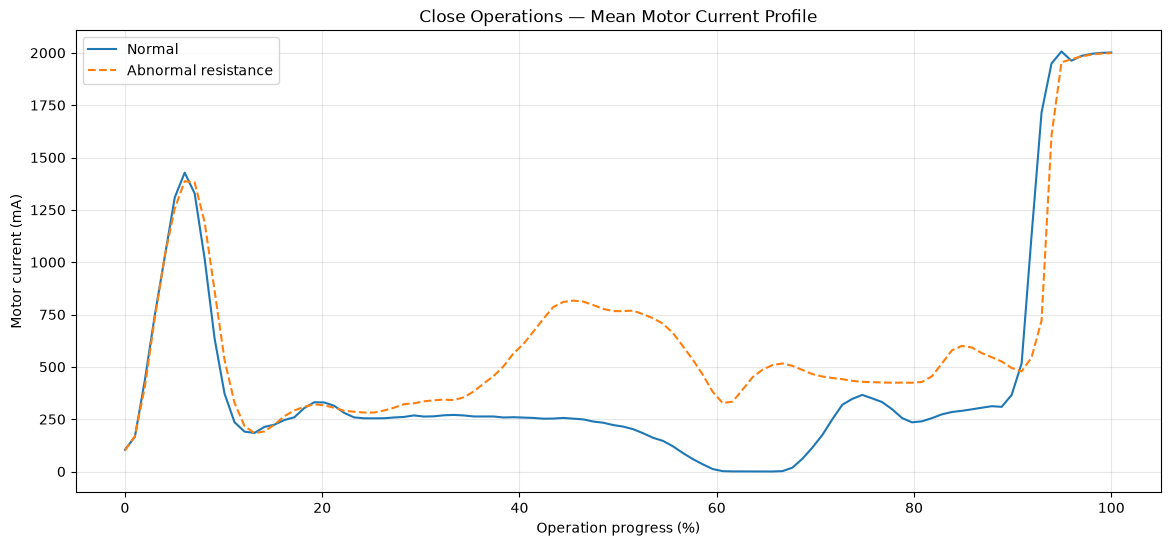

In [22]:
# Build and compare the mean current profiles for Close operations.

normal_close_current = build_profiles(normal_close, "Motor current(mA)")

abnormal_close_current = build_profiles(abnormal_close, "Motor current(mA)")

normal_mean = normal_close_current.mean(axis=0)
abnormal_mean = abnormal_close_current.mean(axis=0)

plt.figure(figsize=(14, 6))

plt.plot(x, normal_mean, label="Normal")

plt.plot(x, abnormal_mean, linestyle="--", label="Abnormal resistance")

plt.xlabel("Operation progress (%)")
plt.ylabel("Motor current (mA)")
plt.title("Close Operations — Mean Motor Current Profile")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

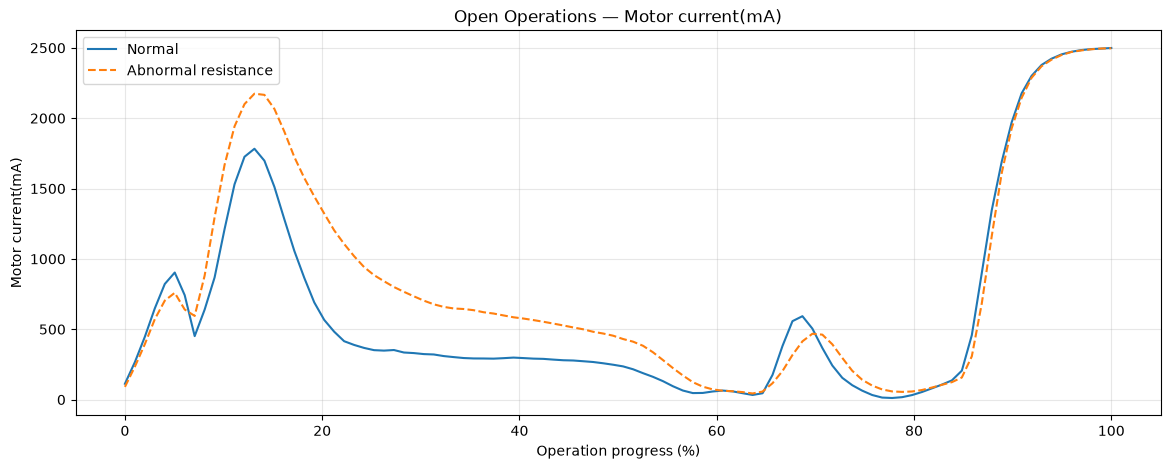

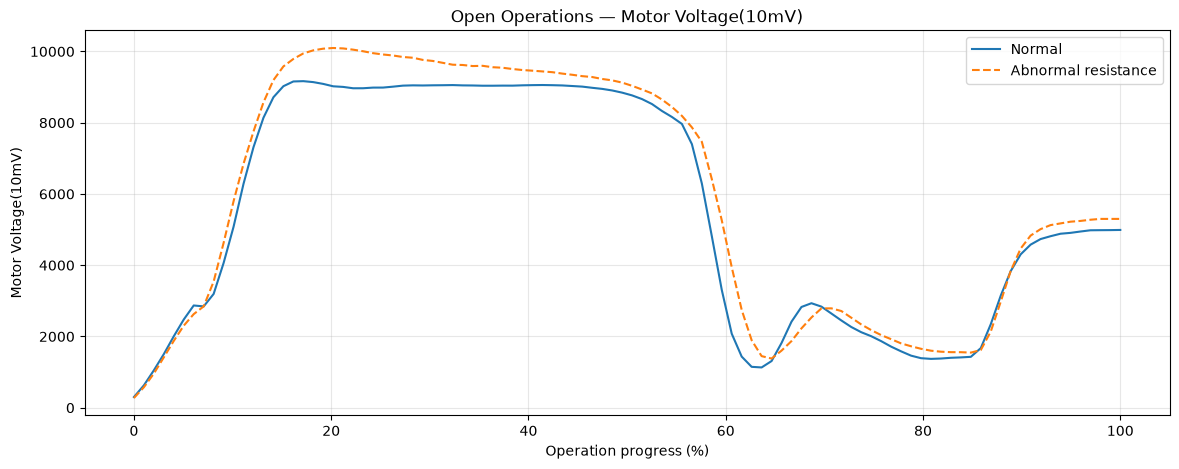

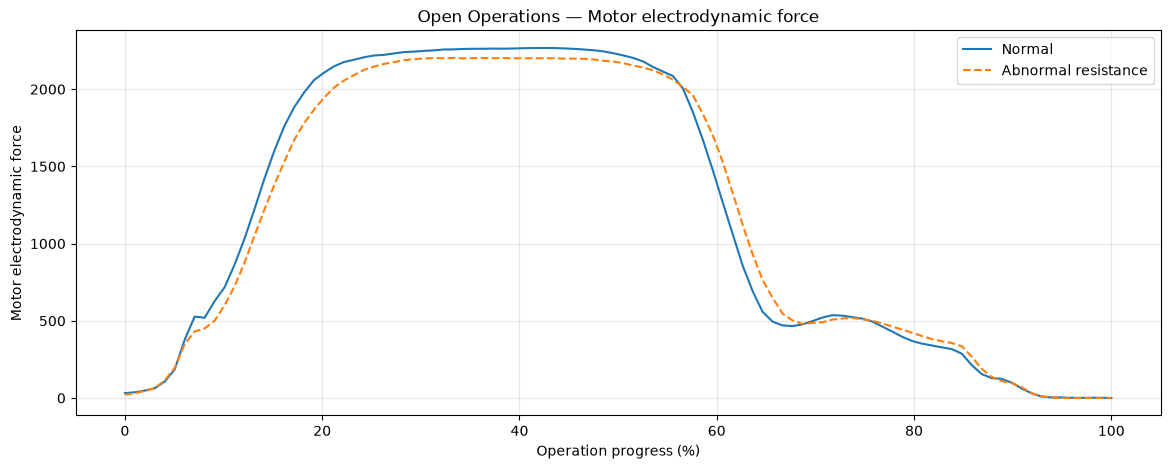

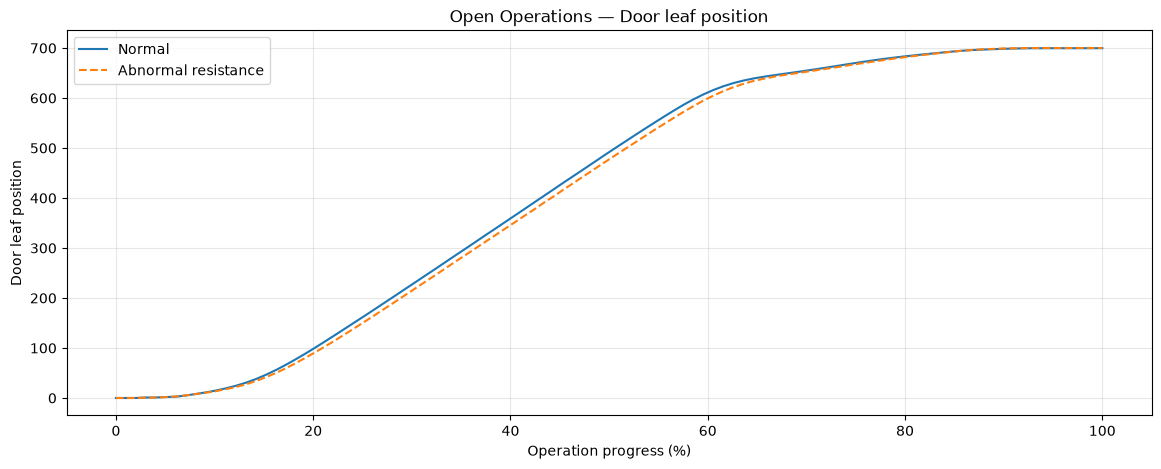

In [23]:
# Compare mean Normal and Abnormal profiles for each main sensor during Open operations.

for signal in signals:
    normal_profiles = build_profiles(normal_open, signal)

    abnormal_profiles = build_profiles(abnormal_open, signal)

    normal_mean = normal_profiles.mean(axis=0)
    abnormal_mean = abnormal_profiles.mean(axis=0)

    plt.figure(figsize=(14, 5))

    plt.plot(x, normal_mean, label="Normal")

    plt.plot(x, abnormal_mean, linestyle="--", label="Abnormal resistance")

    plt.xlabel("Operation progress (%)")
    plt.ylabel(signal)

    plt.title(f"Open Operations — {signal}")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

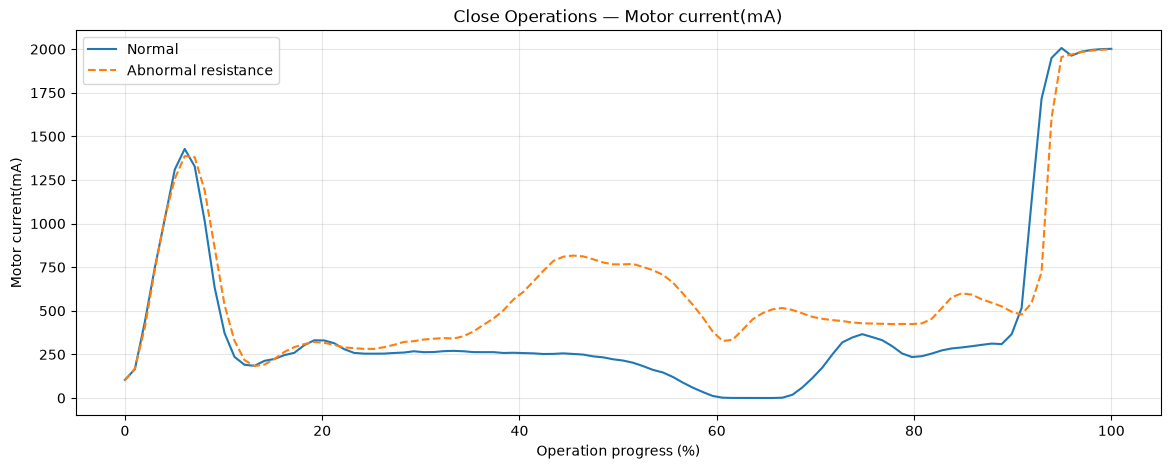

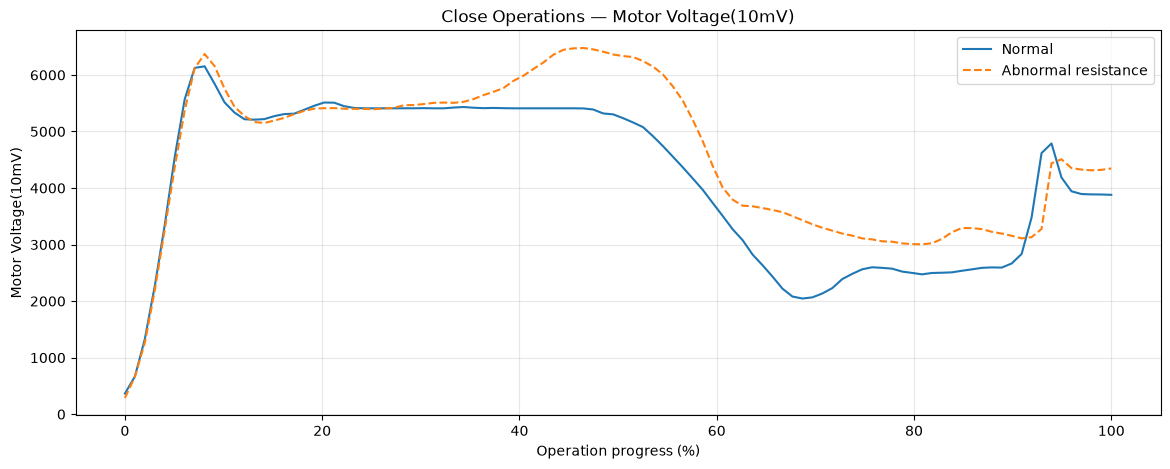

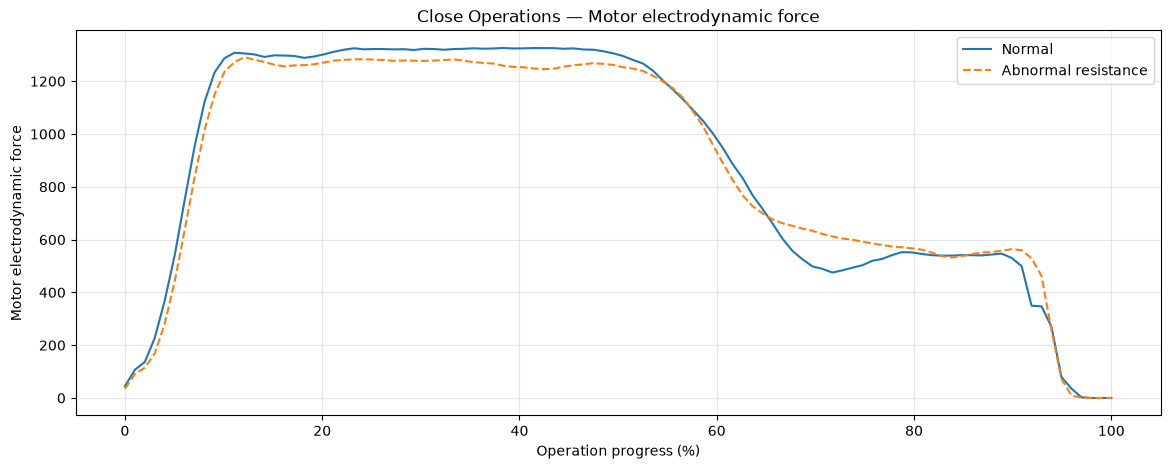

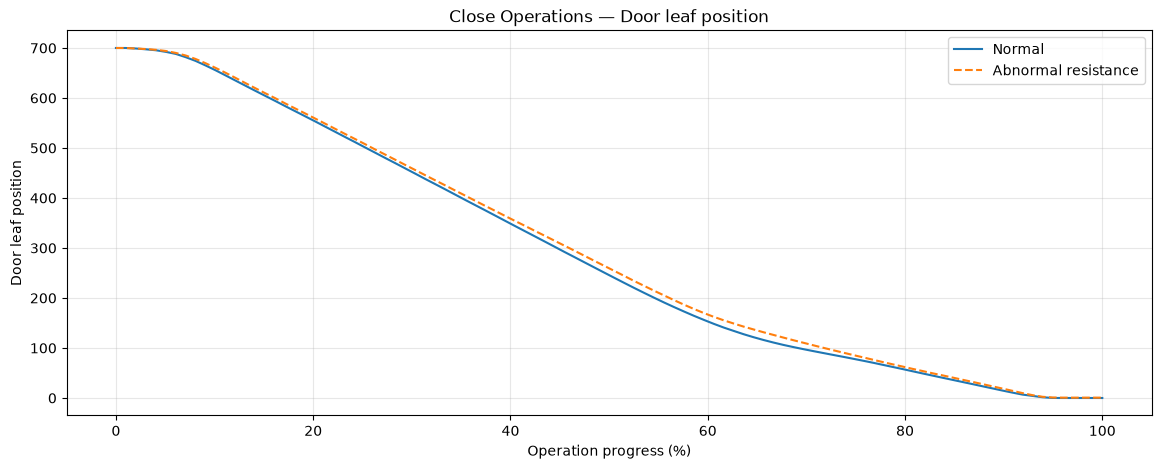

In [24]:
# Compare mean Normal and Abnormal profiles for each main sensor during Close operations.

for signal in signals:
    normal_profiles = build_profiles(normal_close, signal)

    abnormal_profiles = build_profiles(abnormal_close, signal)

    normal_mean = normal_profiles.mean(axis=0)
    abnormal_mean = abnormal_profiles.mean(axis=0)

    plt.figure(figsize=(14, 5))

    plt.plot(x, normal_mean, label="Normal")

    plt.plot(x, abnormal_mean, linestyle="--", label="Abnormal resistance")

    plt.xlabel("Operation progress (%)")
    plt.ylabel(signal)

    plt.title(f"Close Operations — {signal}")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

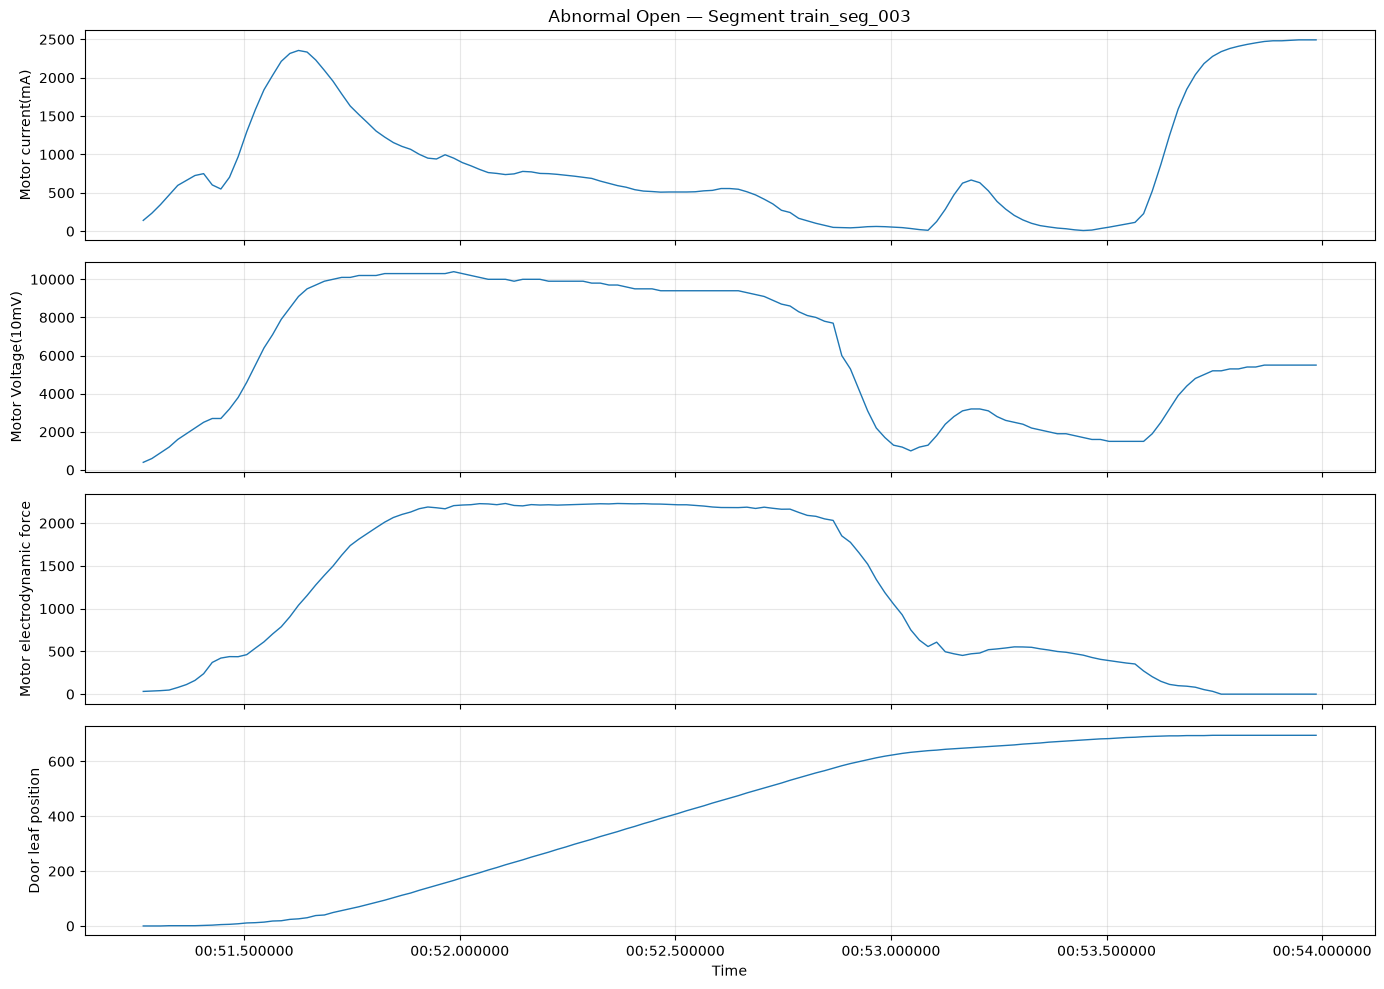

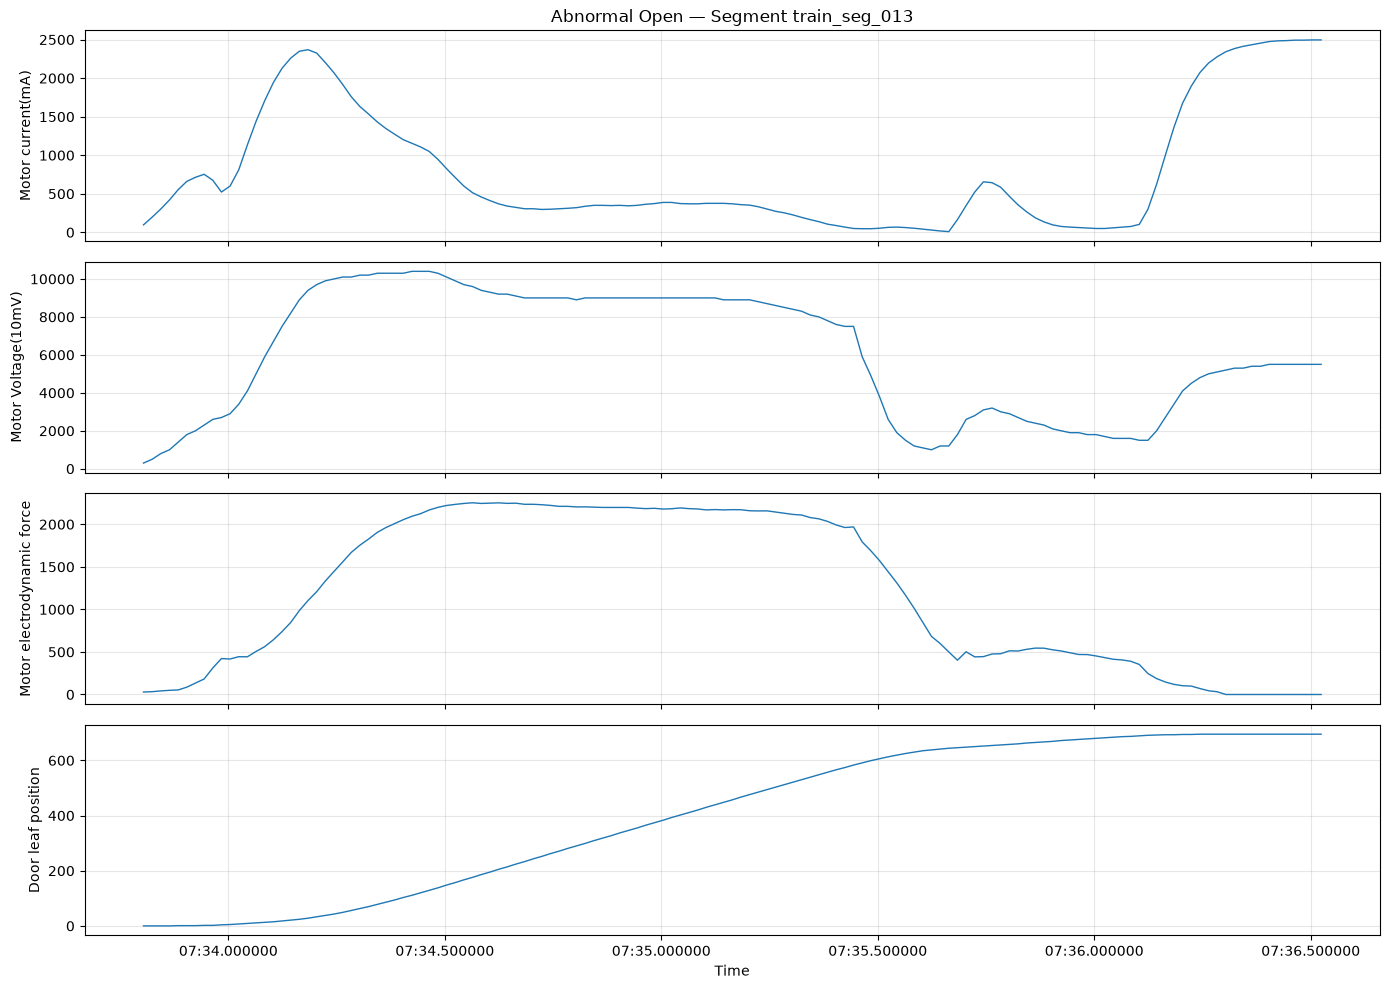

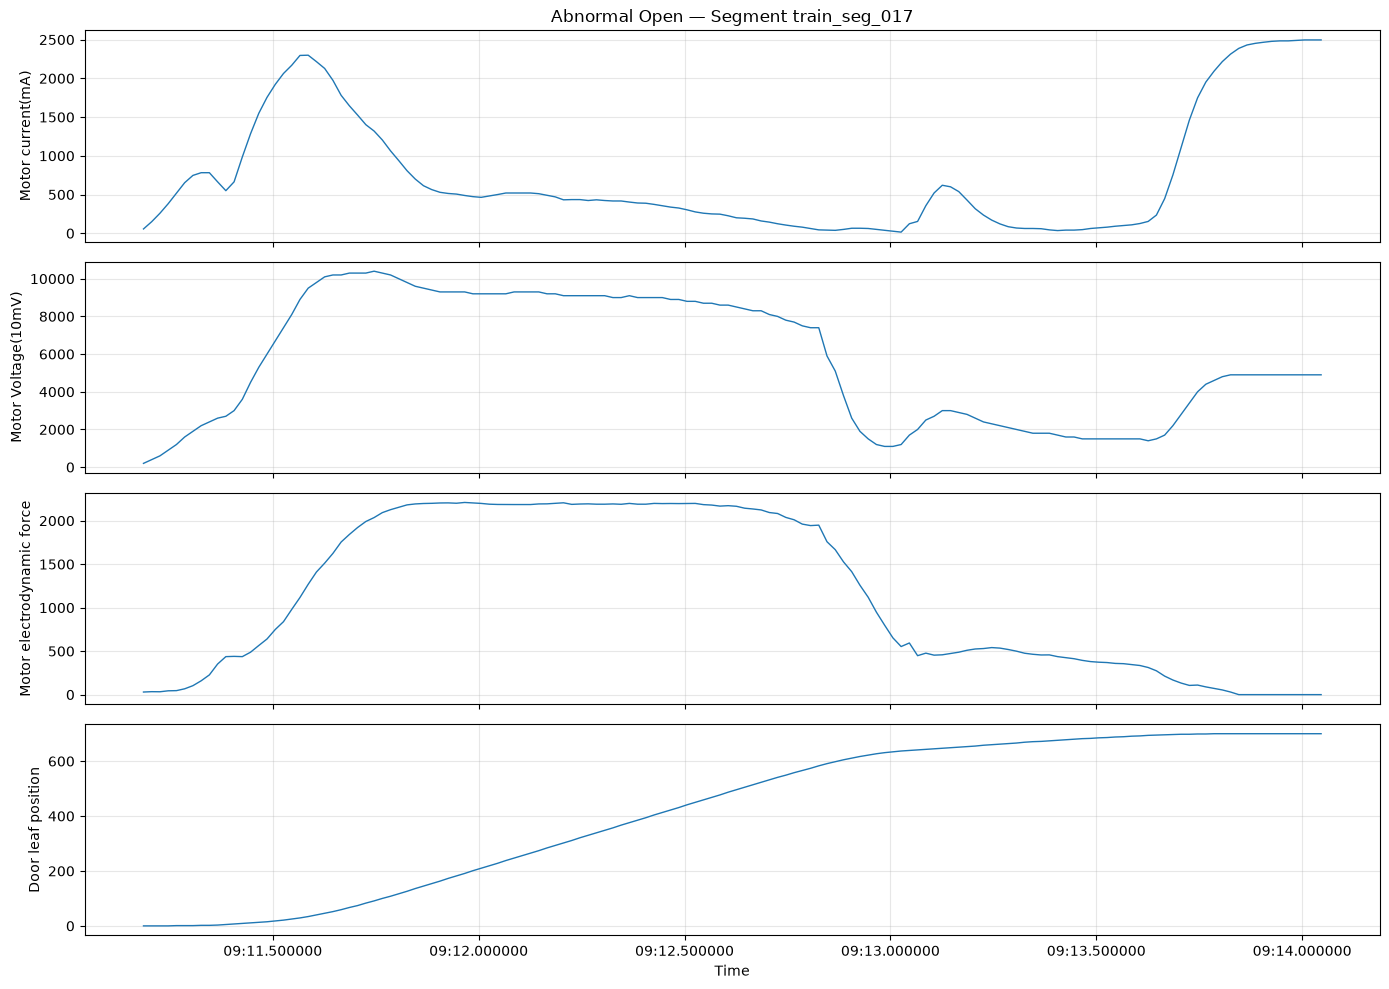

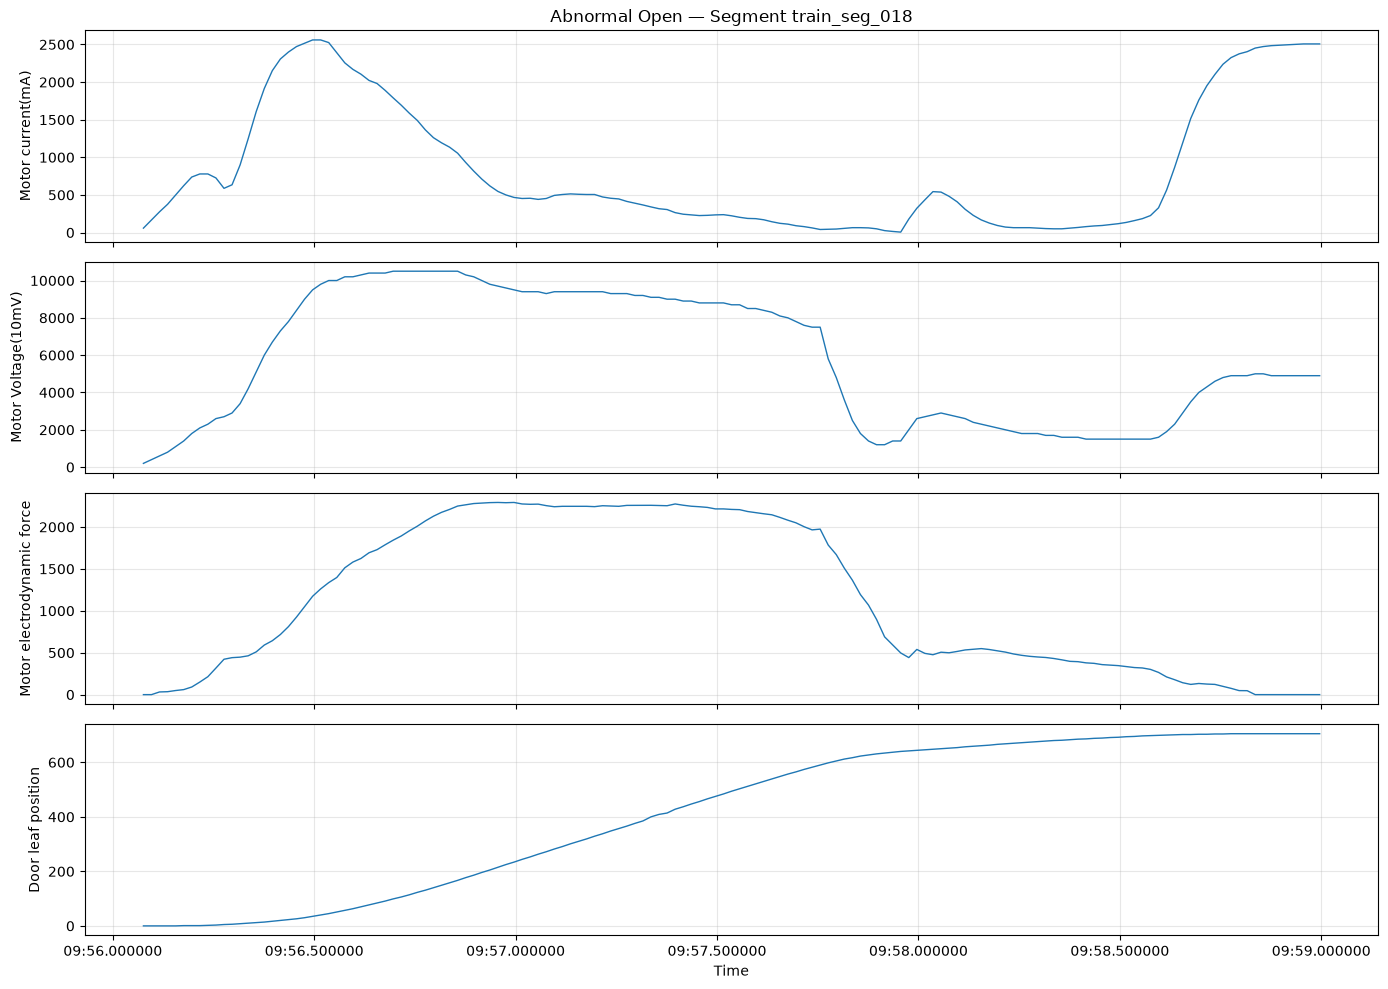

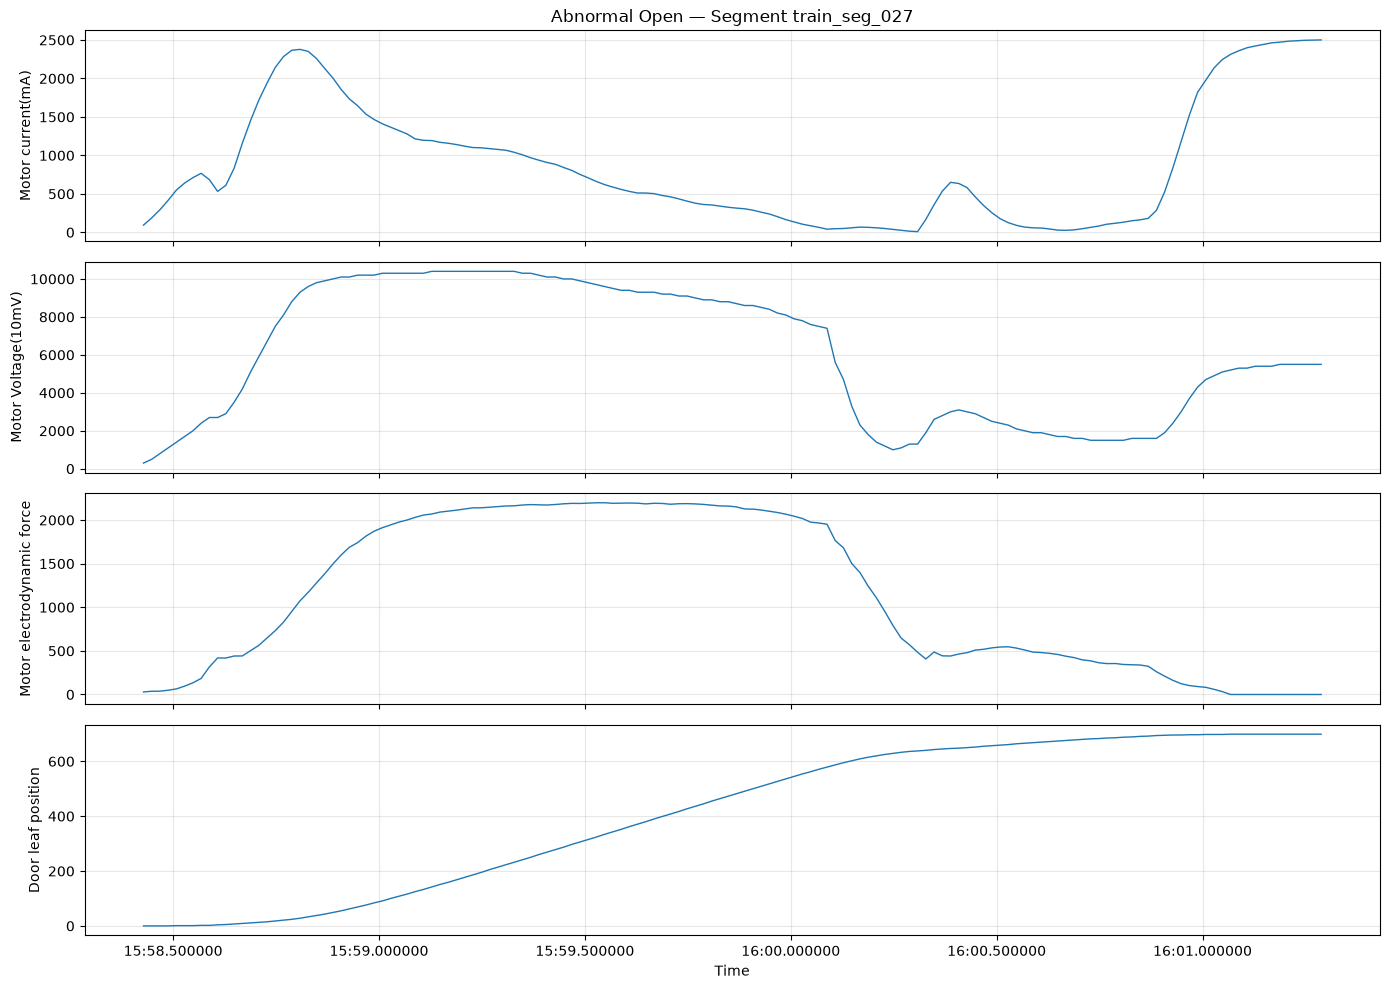

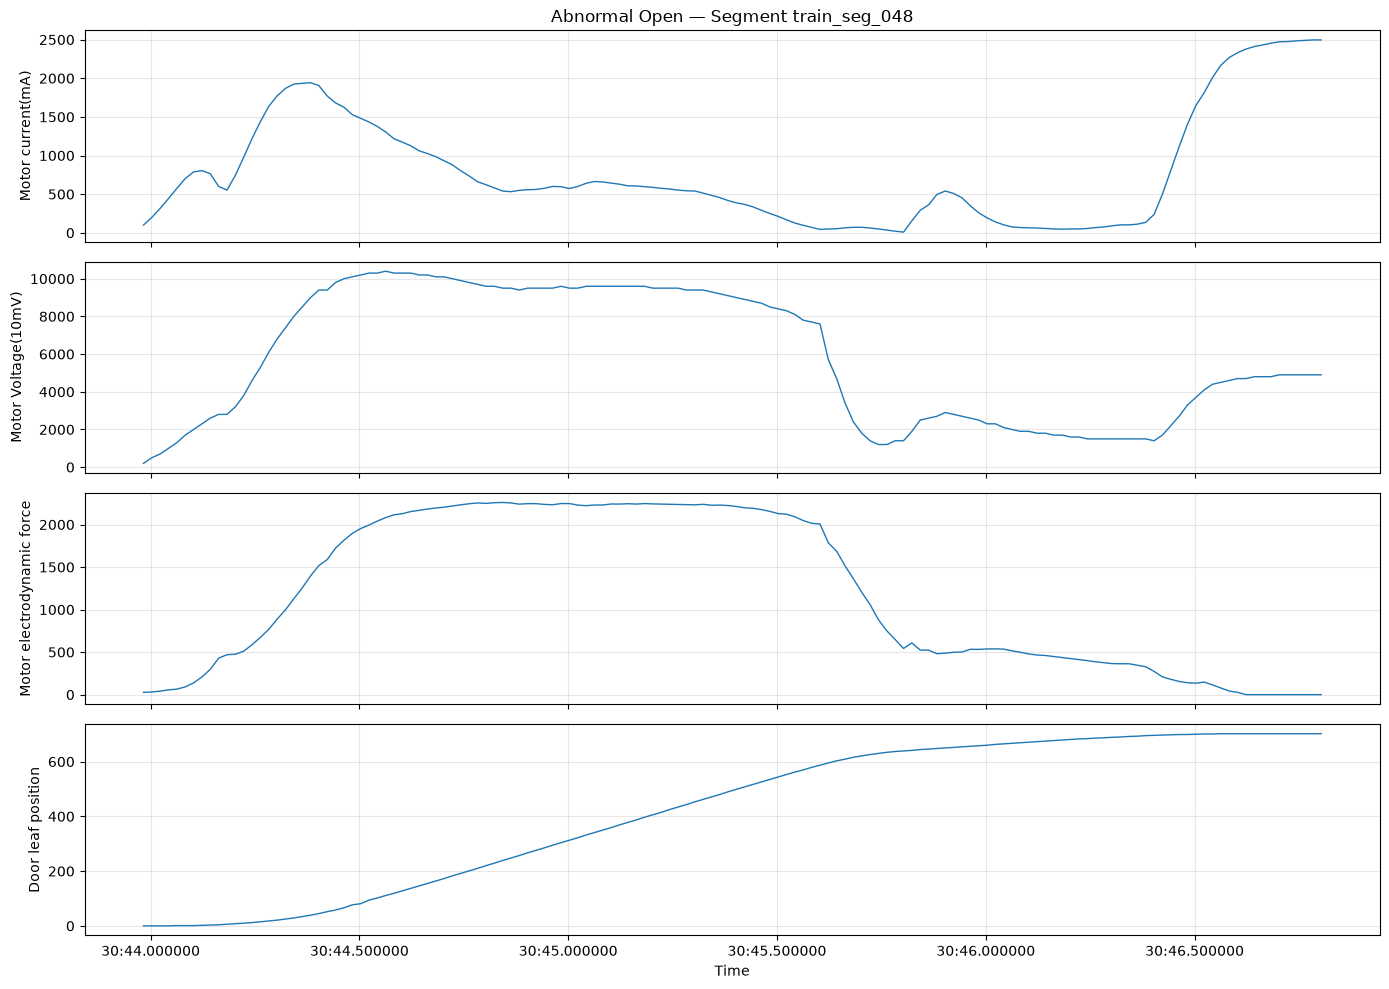

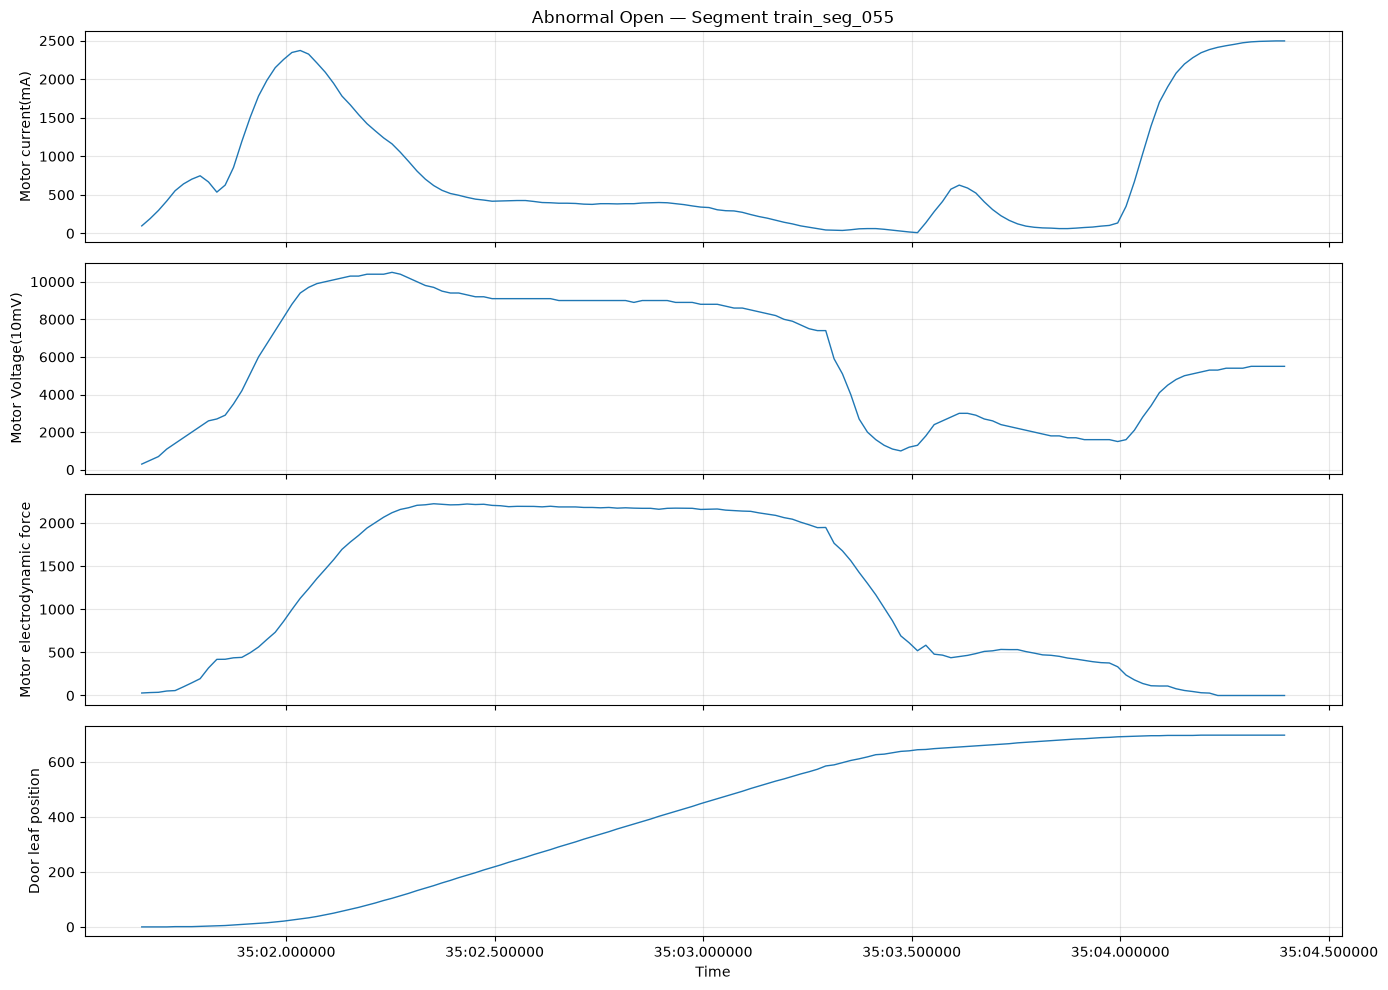

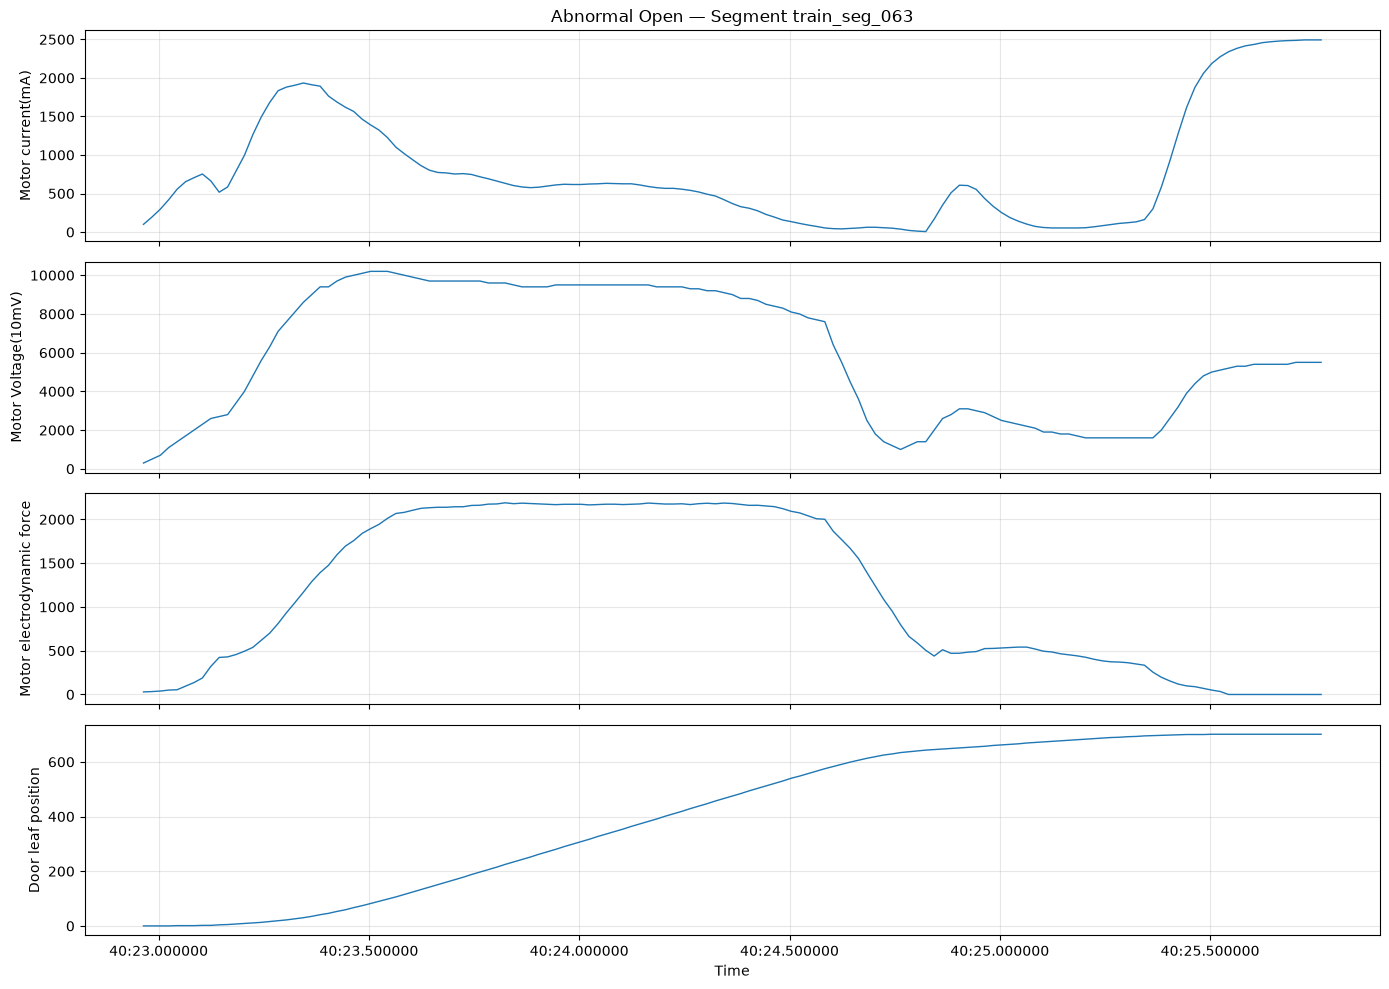

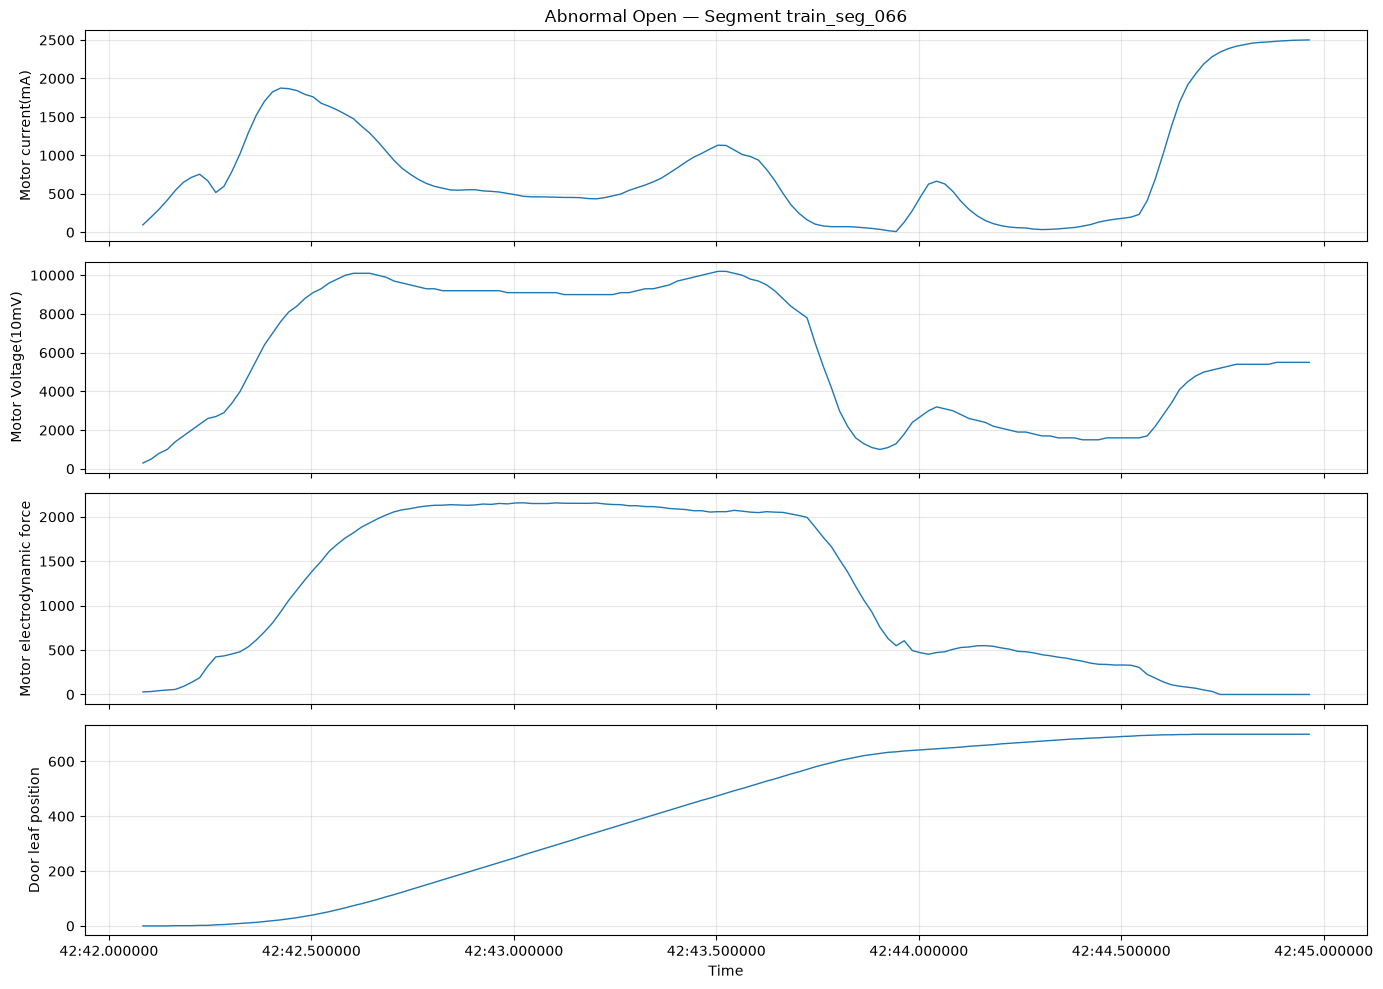

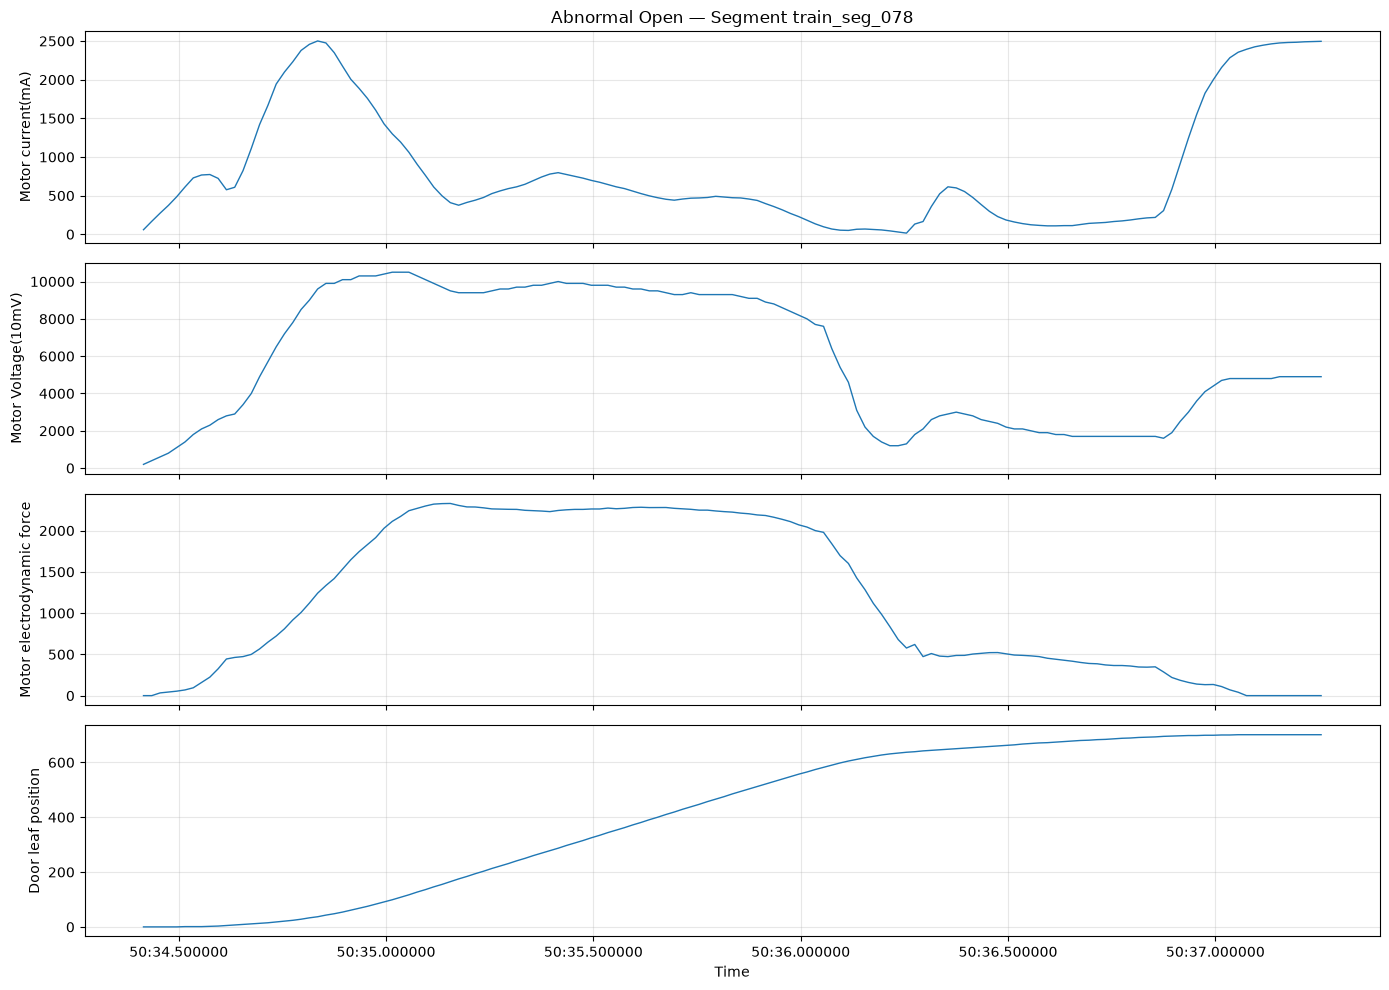

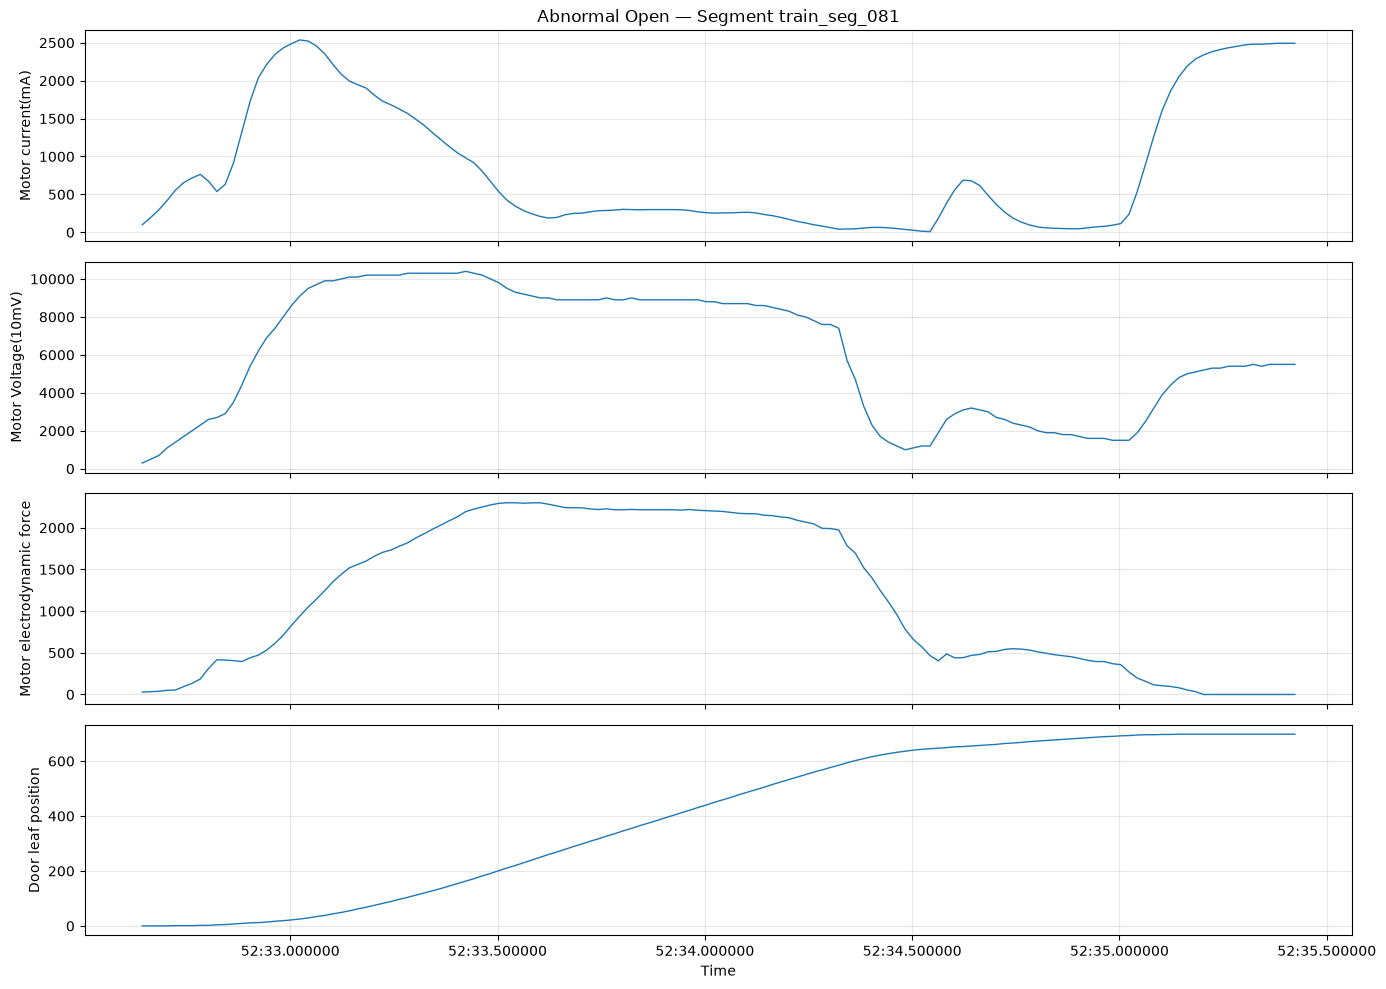

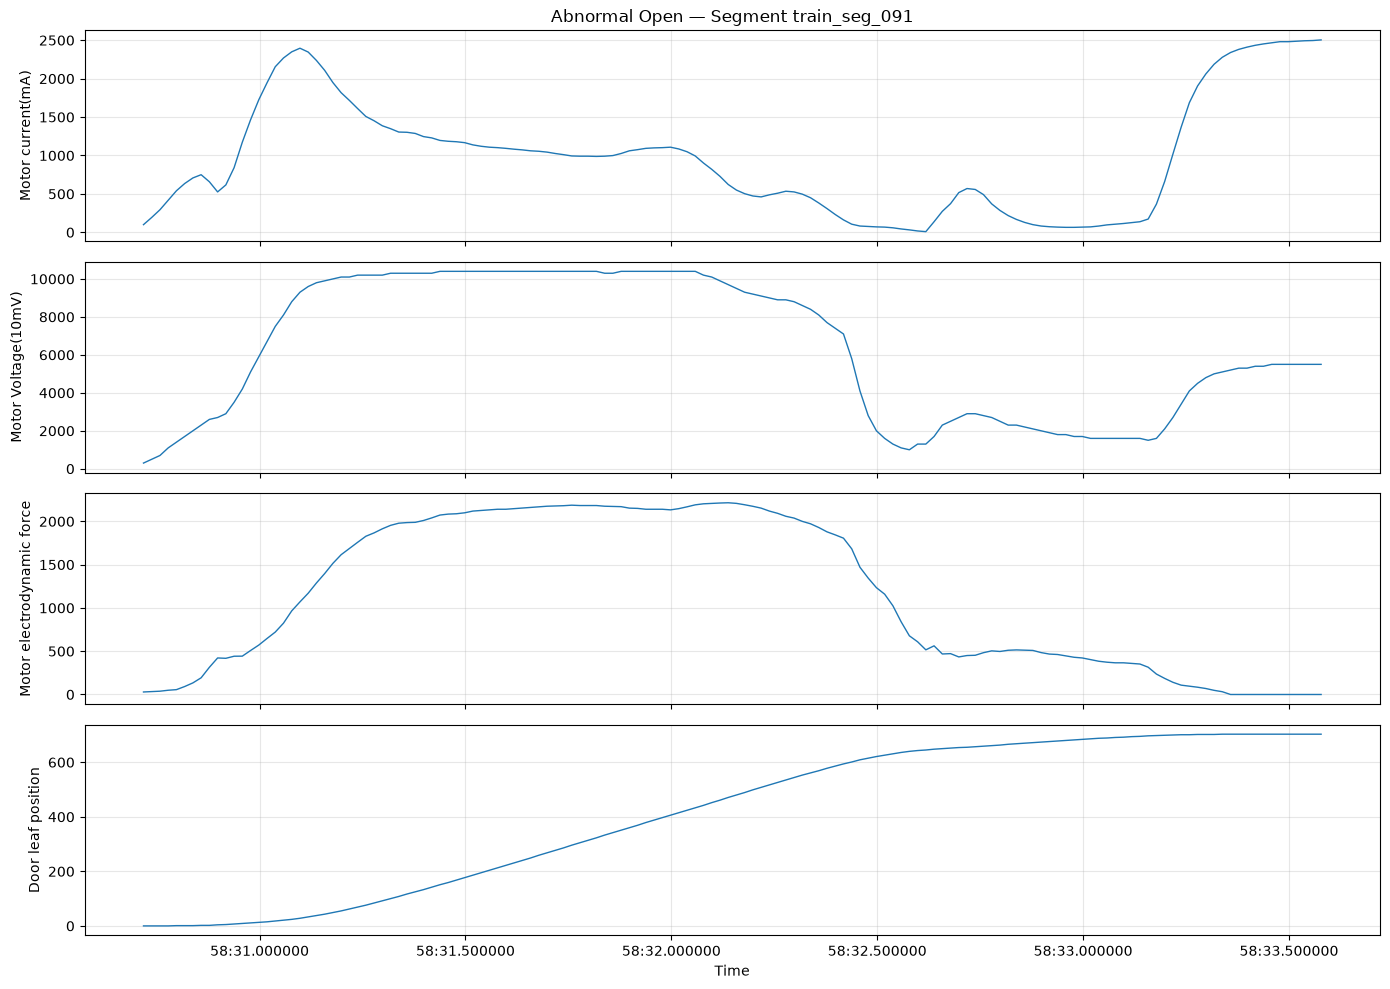

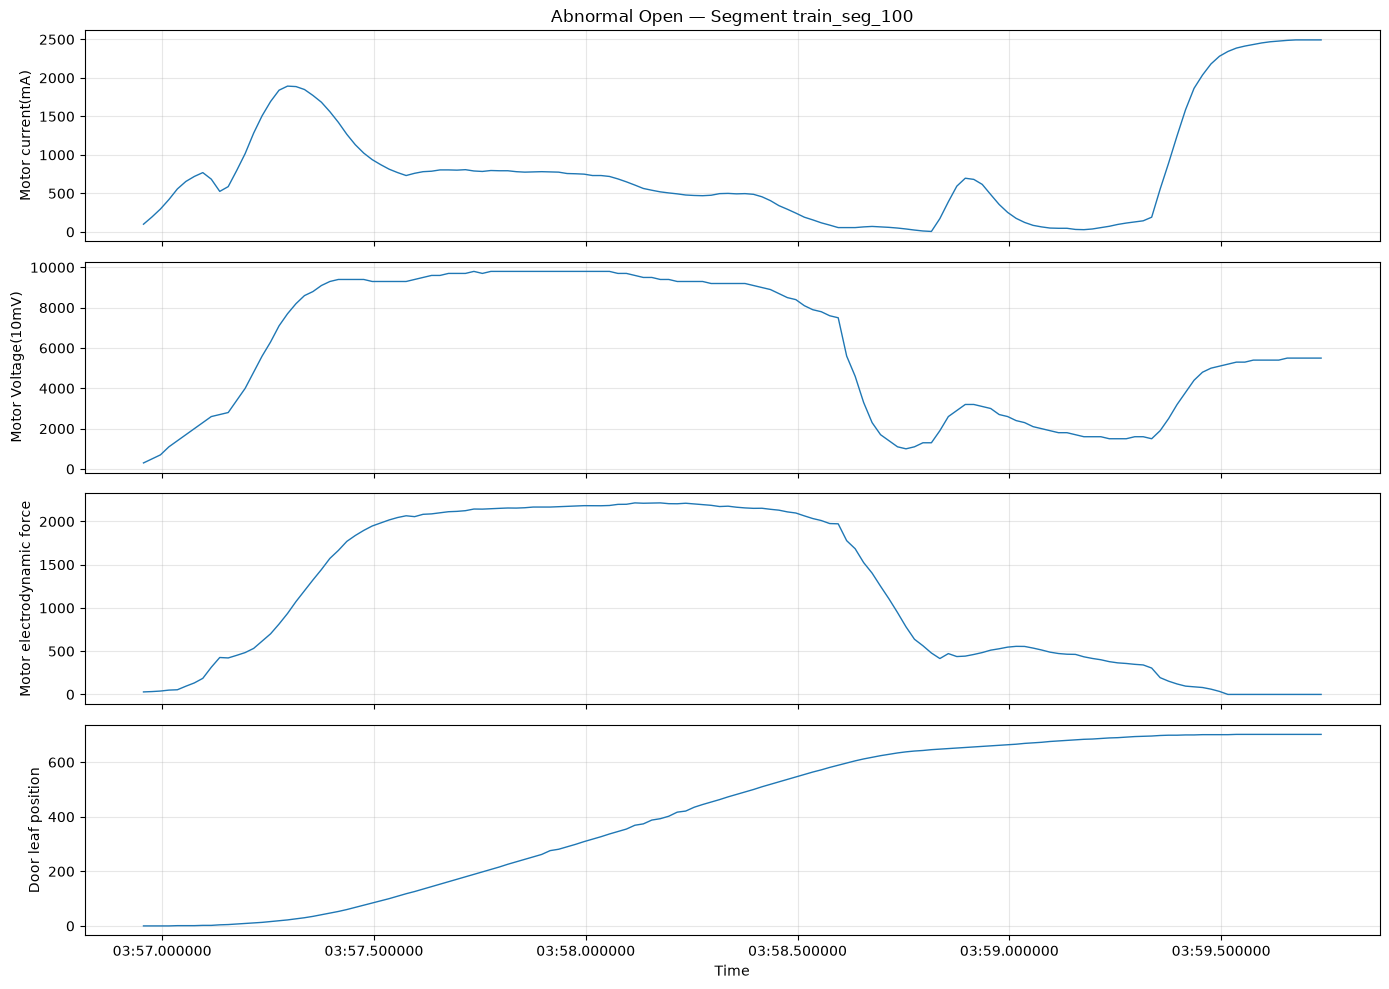

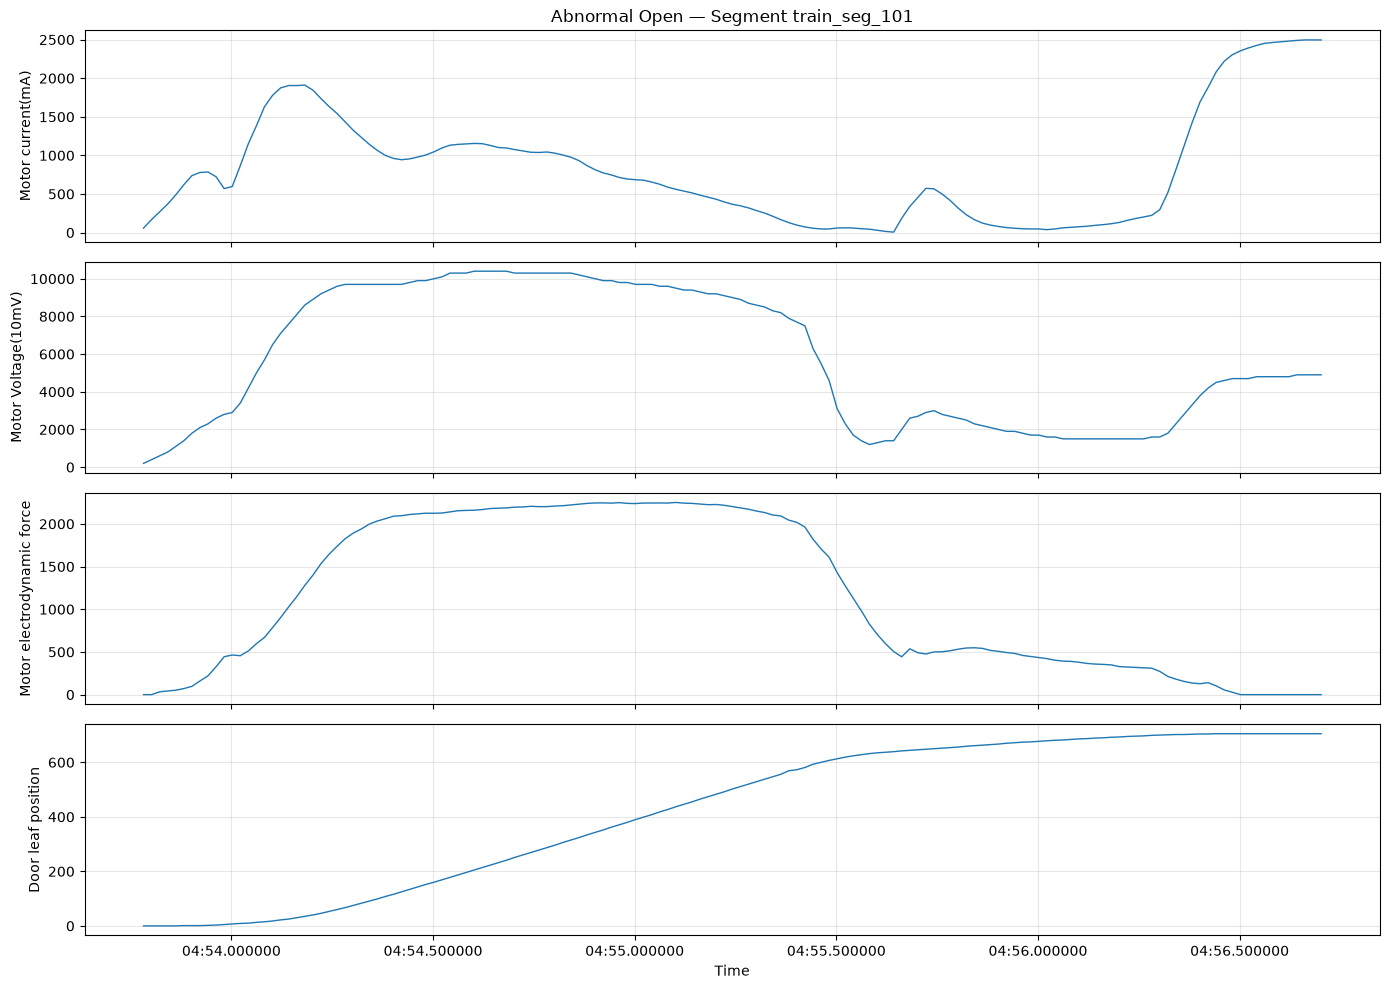

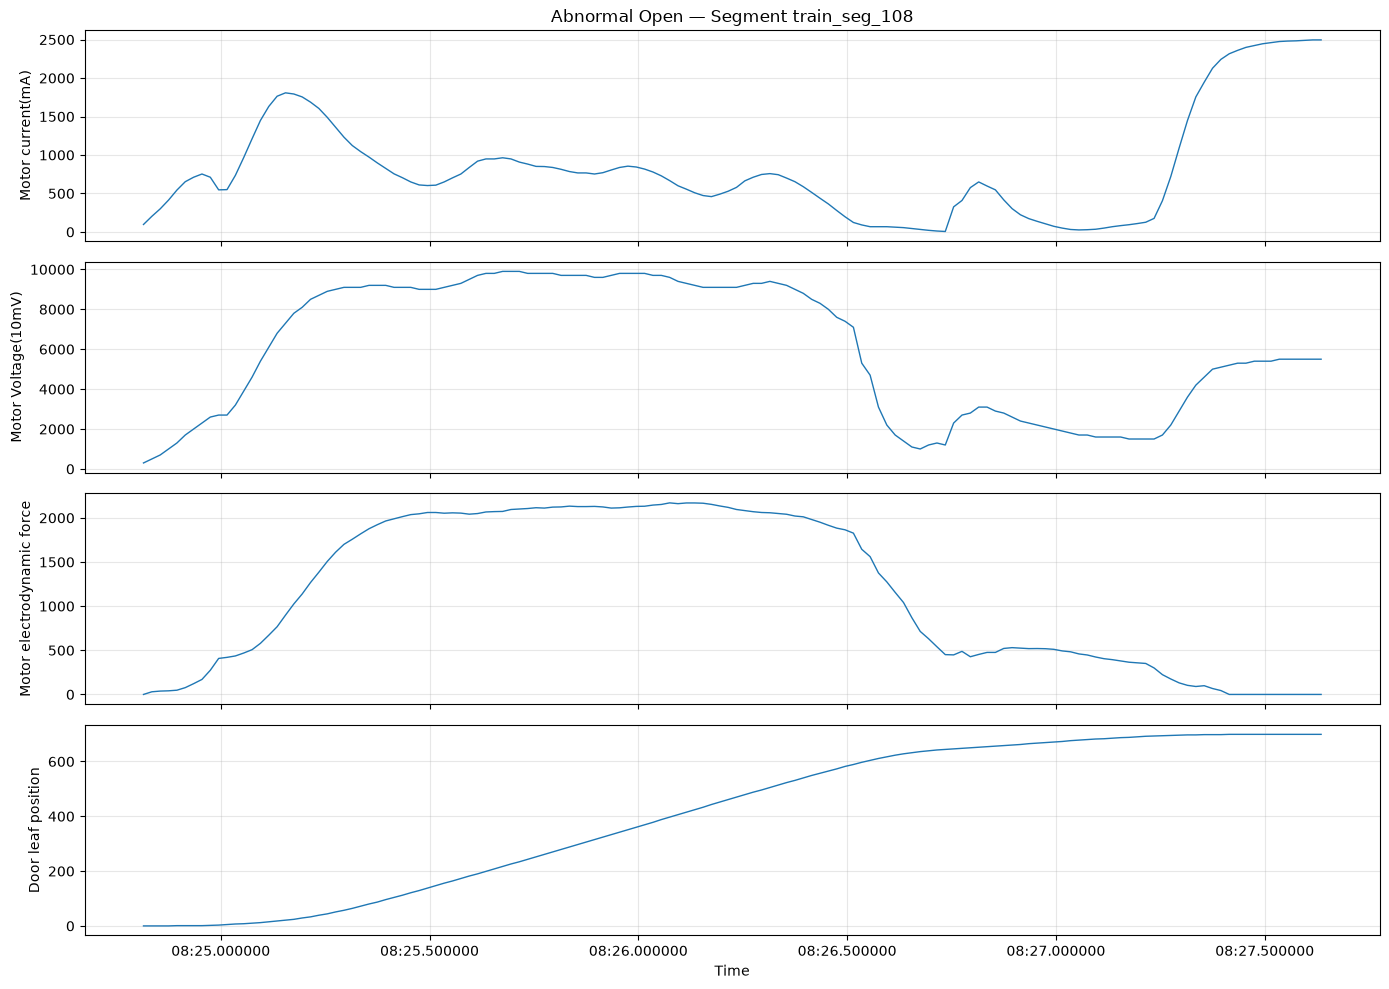

In [25]:
# Plot every abnormal Open cycle separately for the main sensor signals.

for _, segment in abnormal_open.iterrows():
    cycle = extract_cycle(train, segment)

    fig, axes = plt.subplots(len(signals), 1, figsize=(14, 10), sharex=True)

    for ax, signal in zip(axes, signals):
        ax.plot(cycle["timestamp"], cycle[signal], linewidth=1)

        ax.set_ylabel(signal)
        ax.grid(alpha=0.3)

    axes[0].set_title(f"Abnormal Open — Segment {segment['segment_id']}")

    axes[-1].set_xlabel("Time")

    plt.tight_layout()
    plt.show()

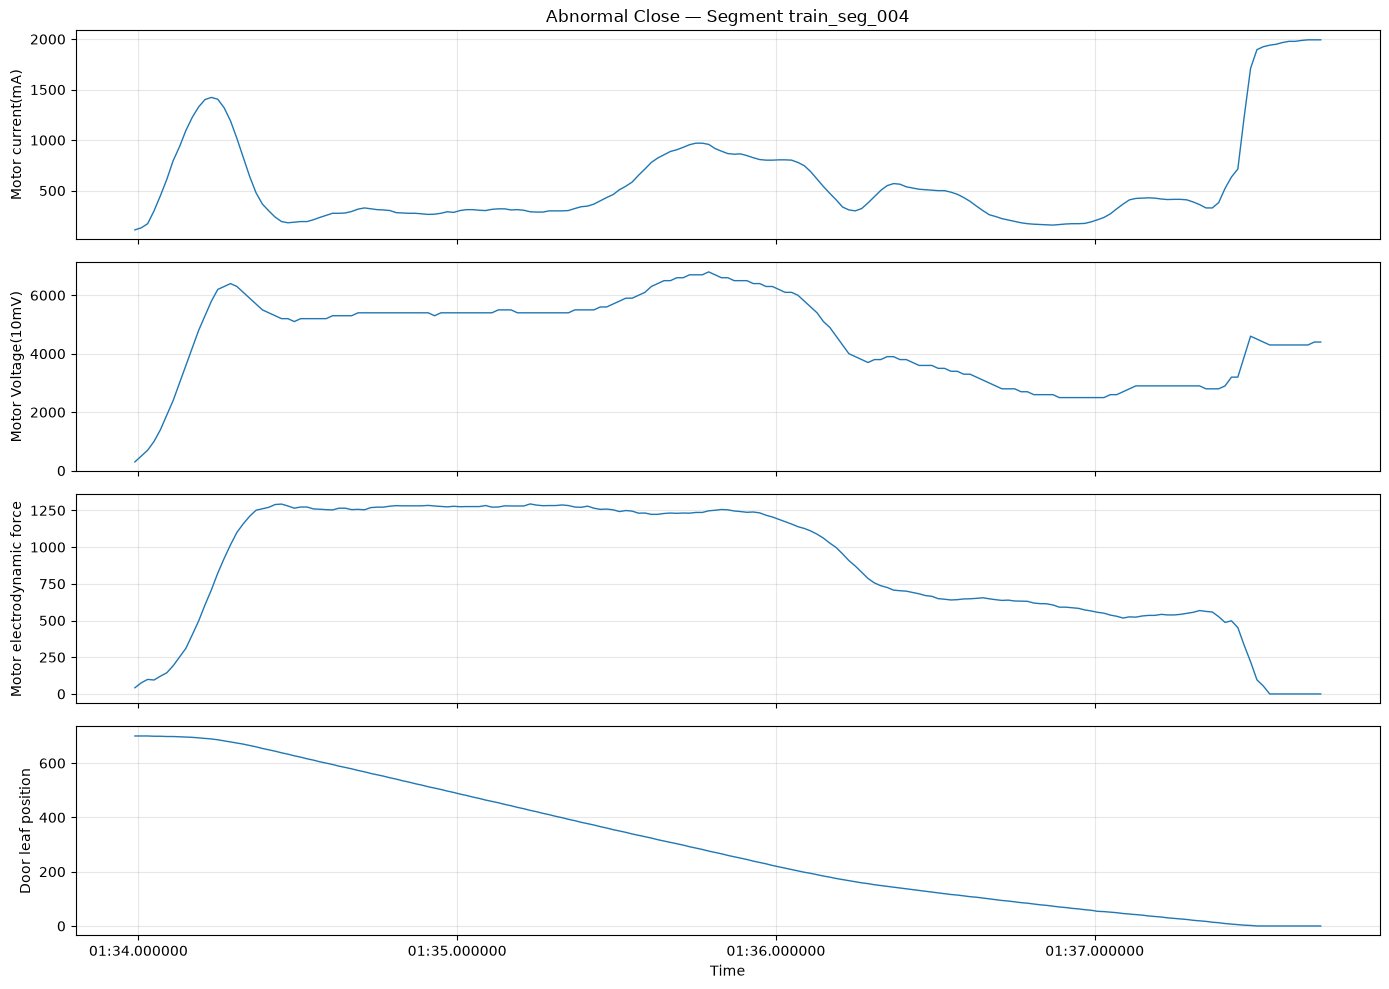

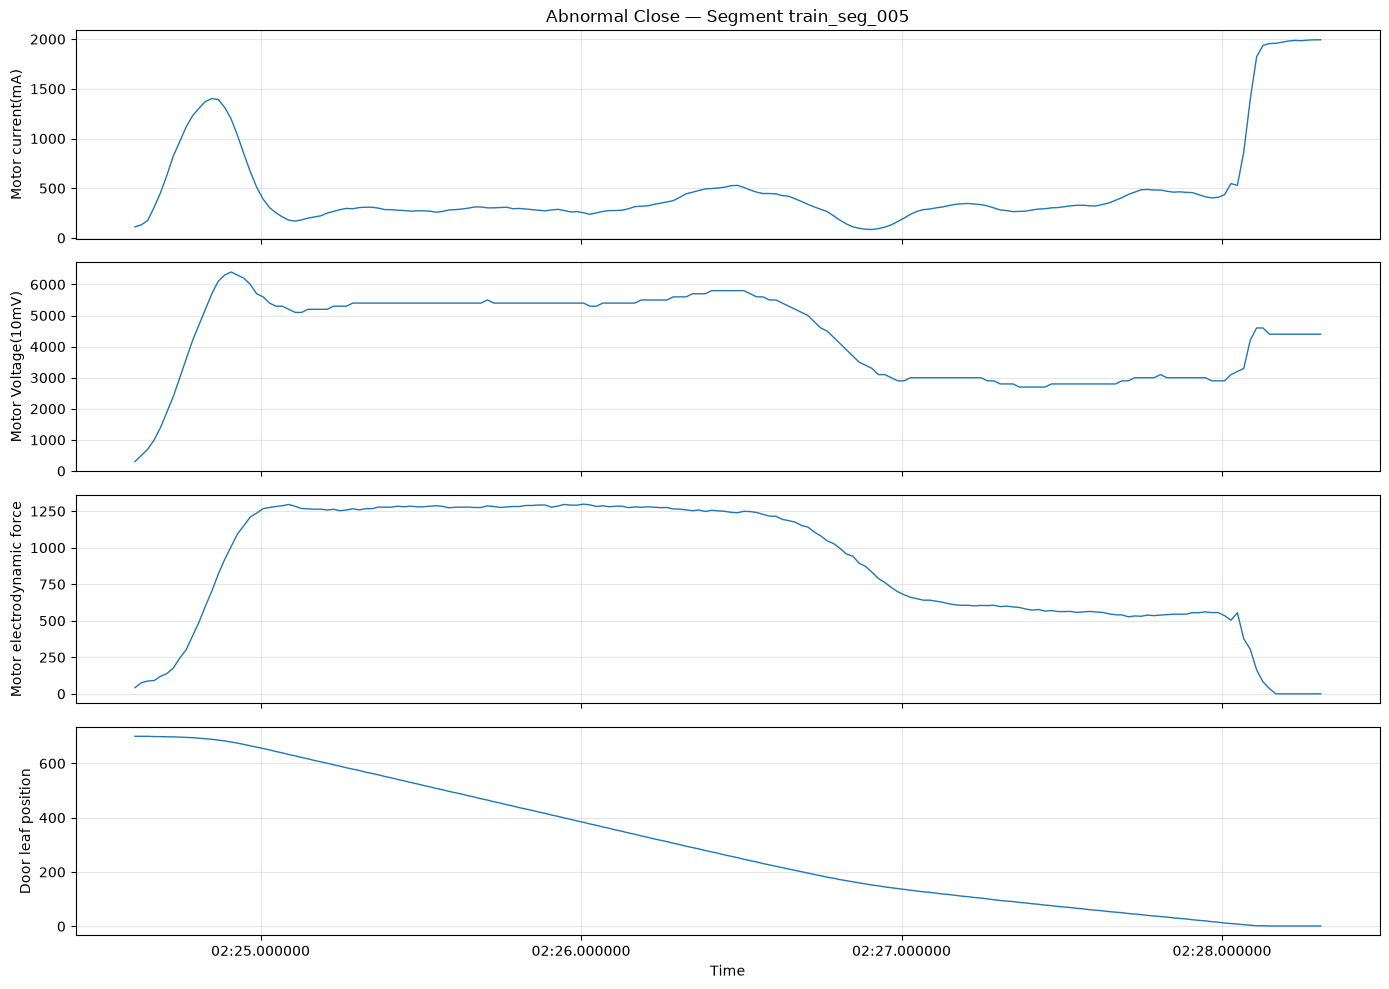

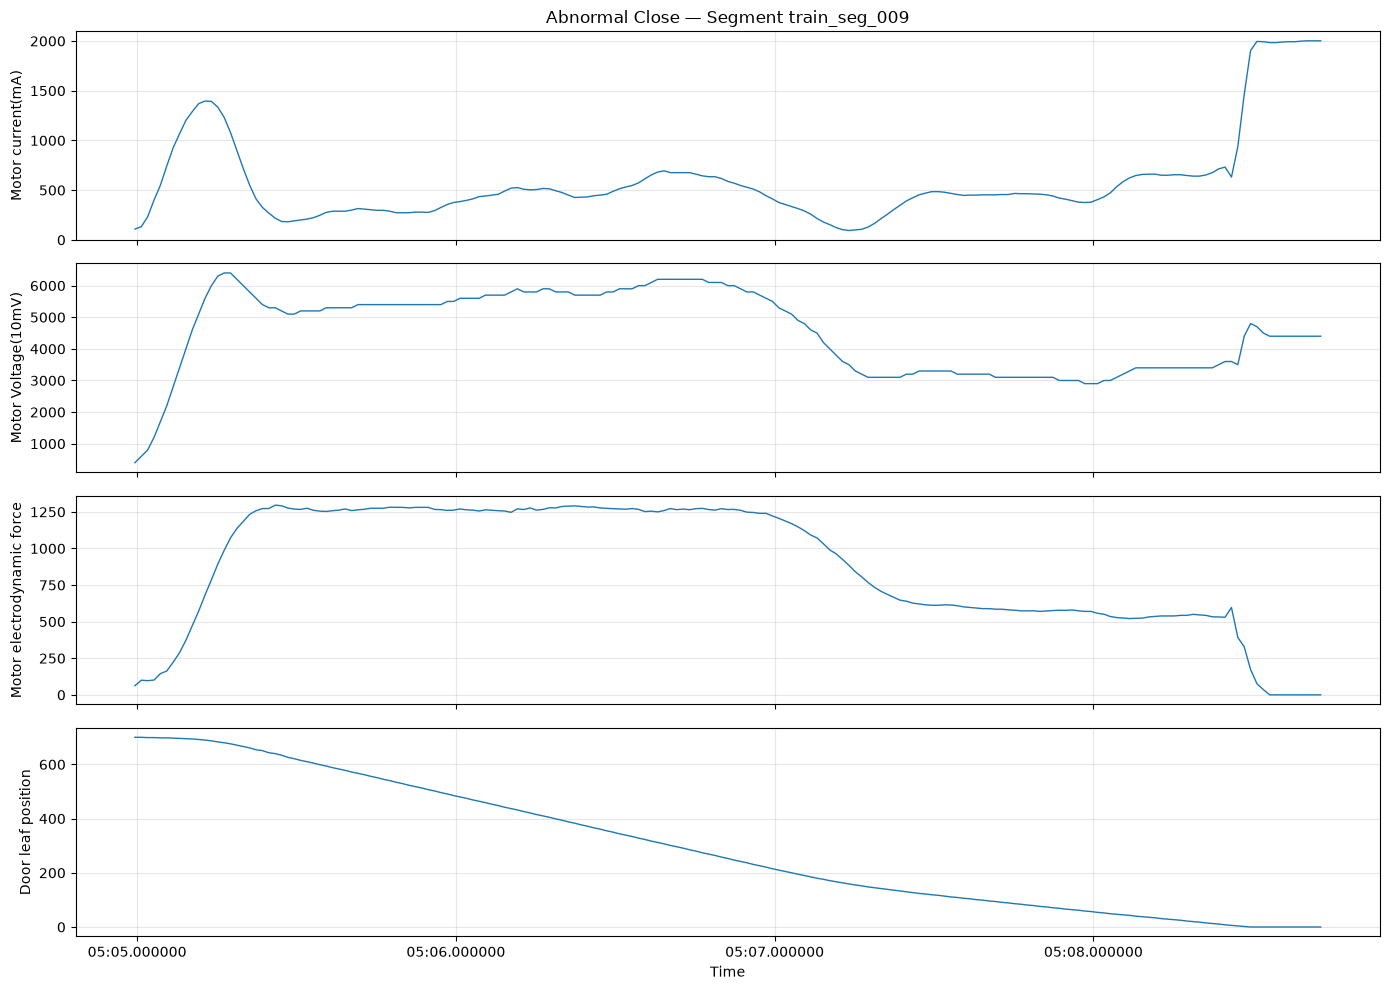

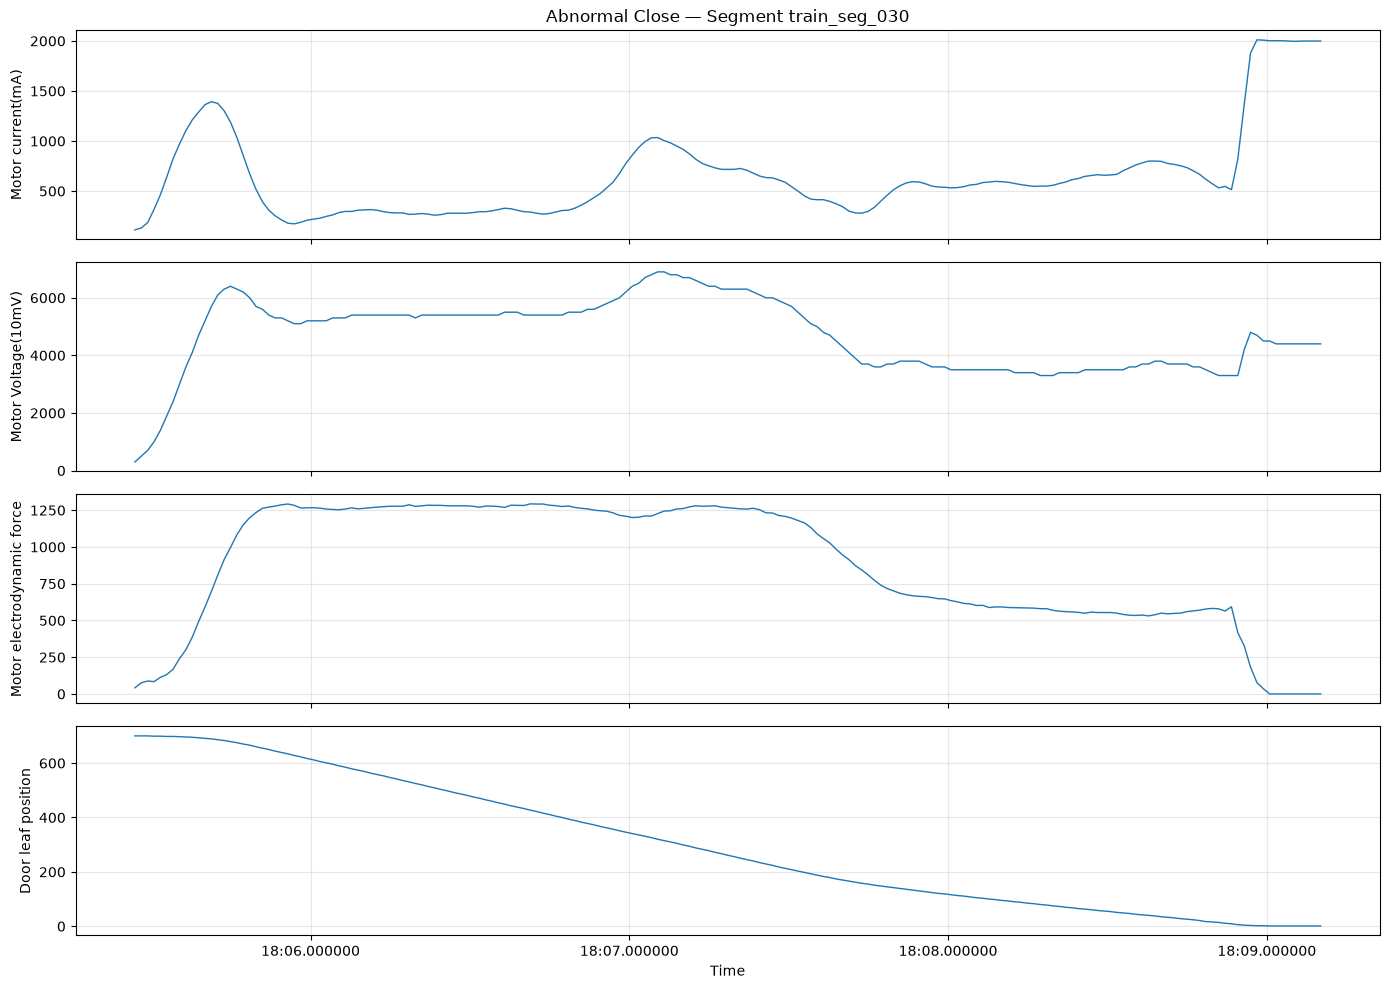

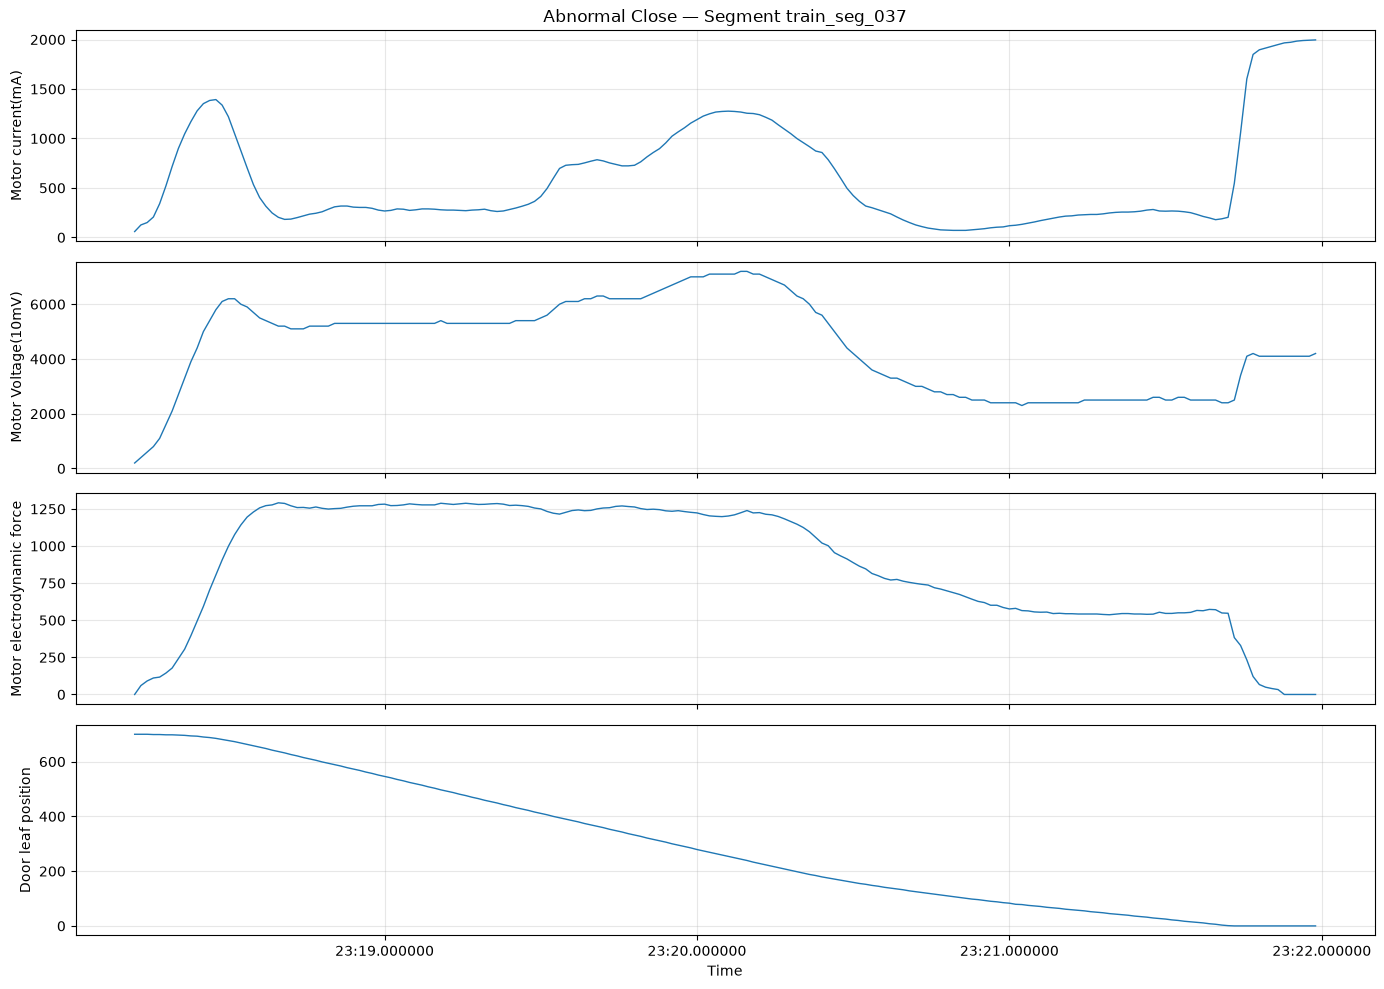

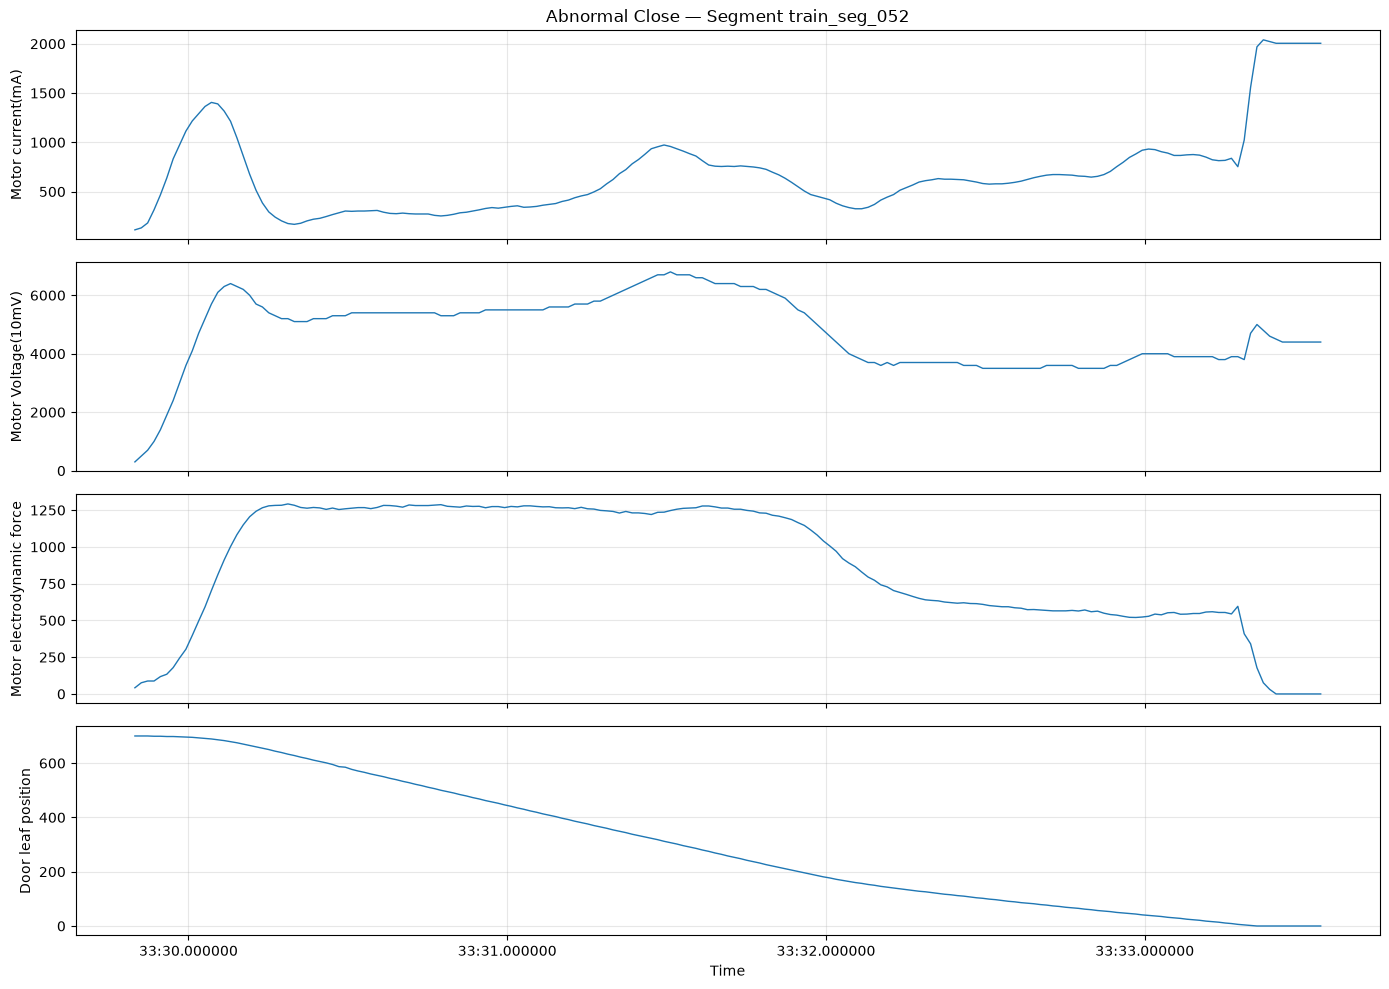

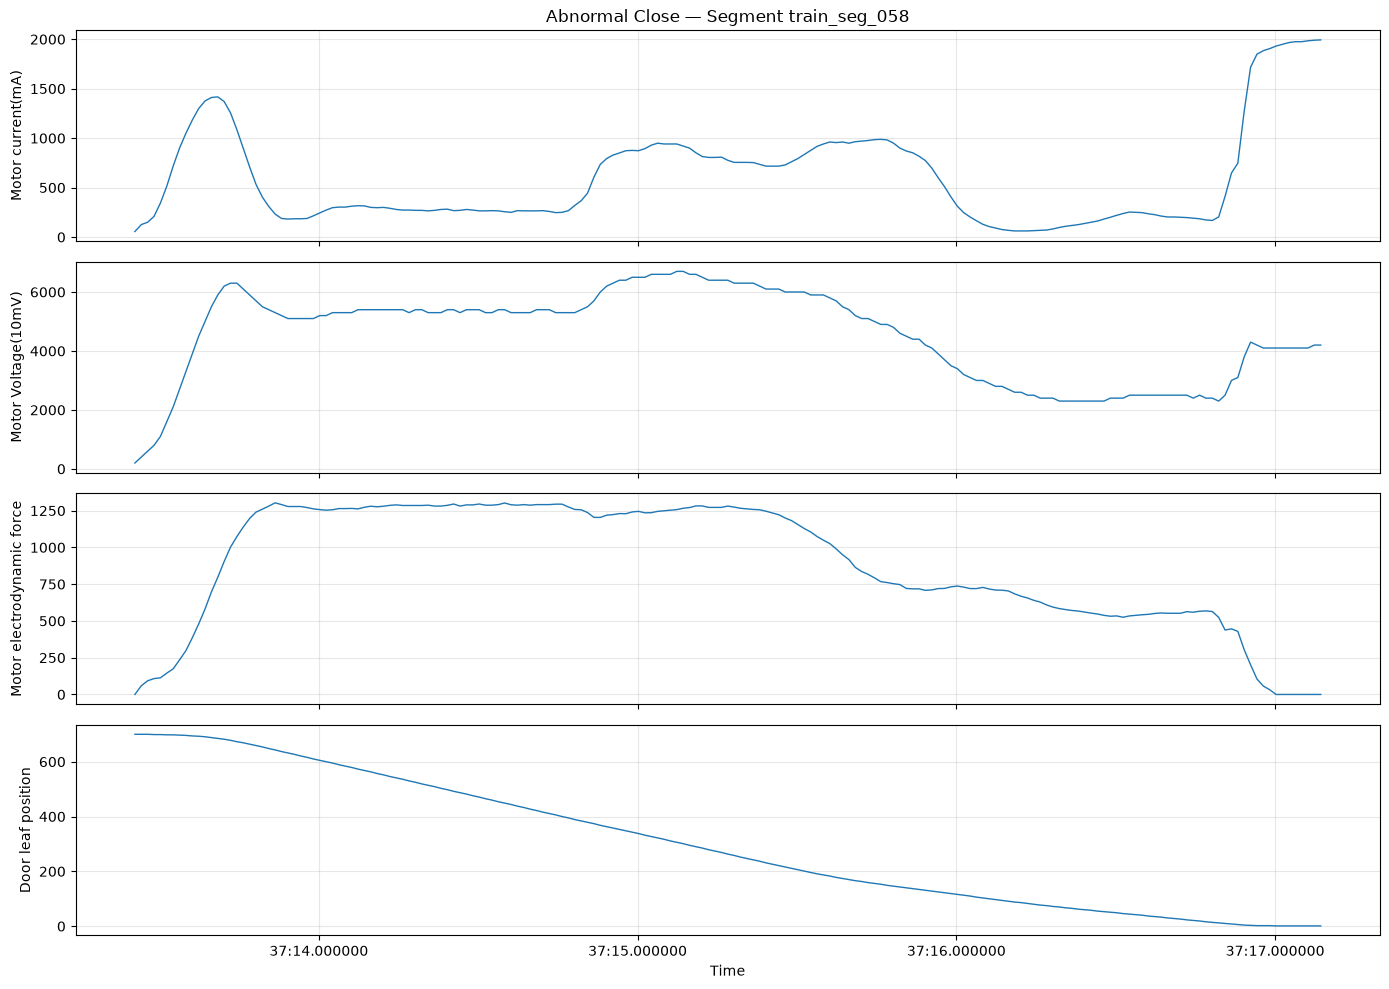

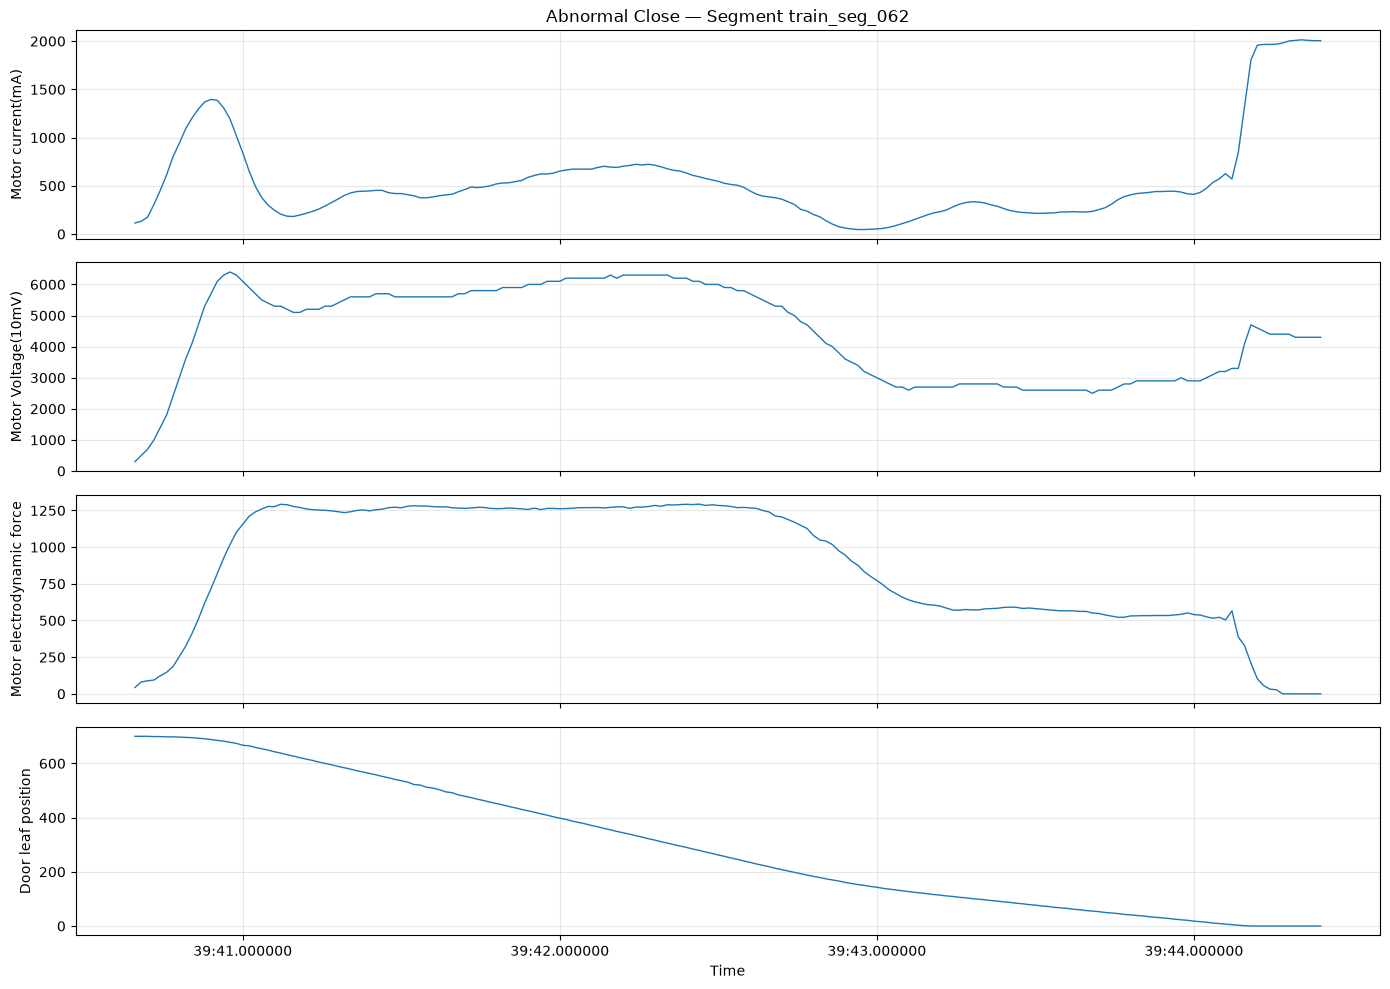

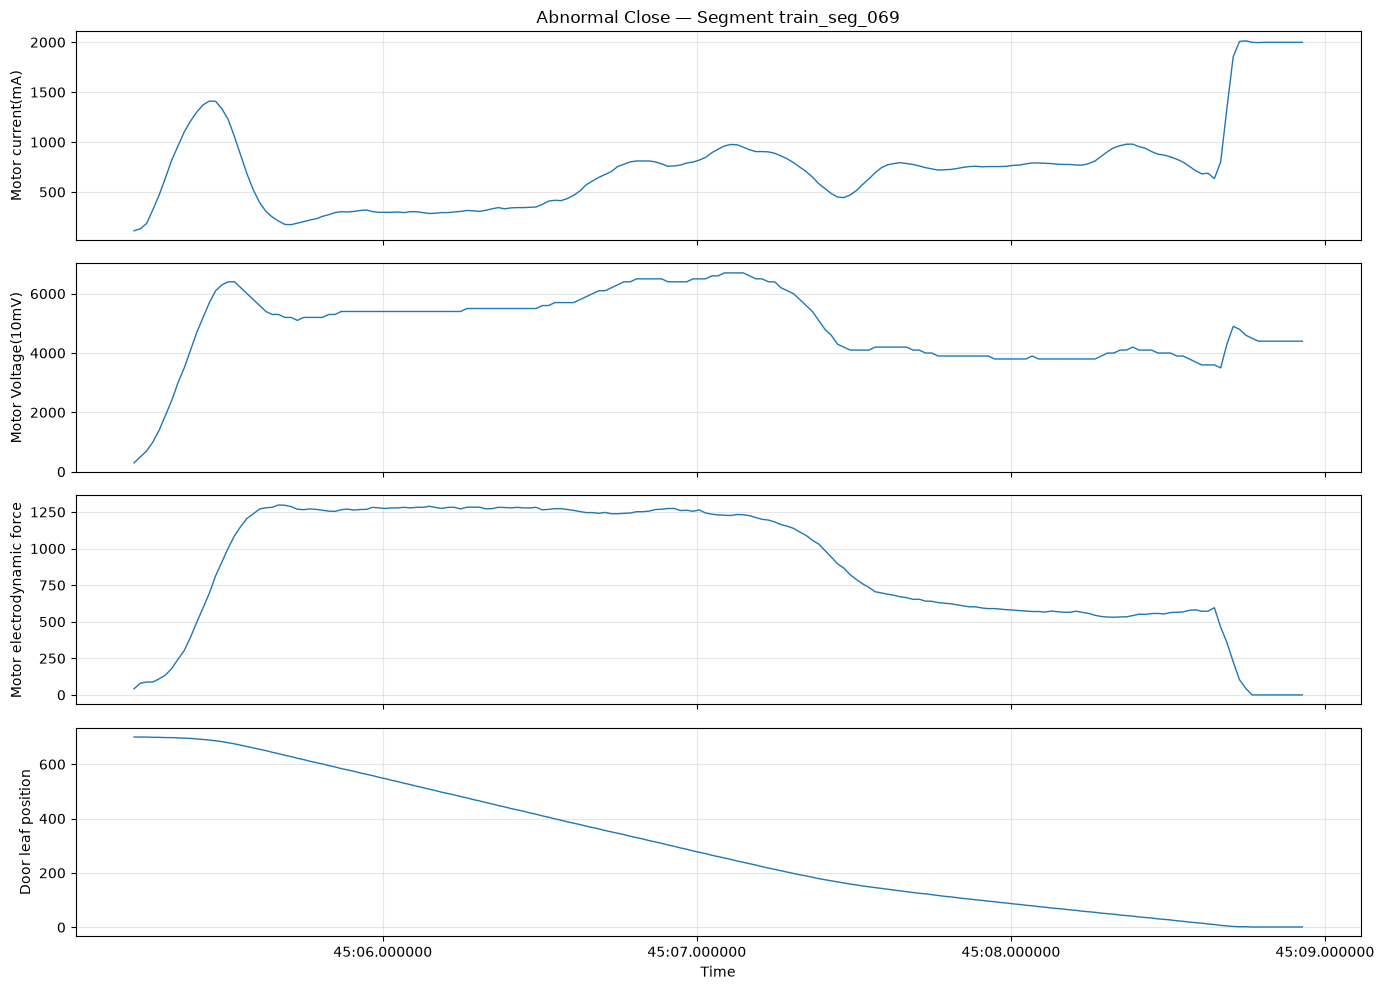

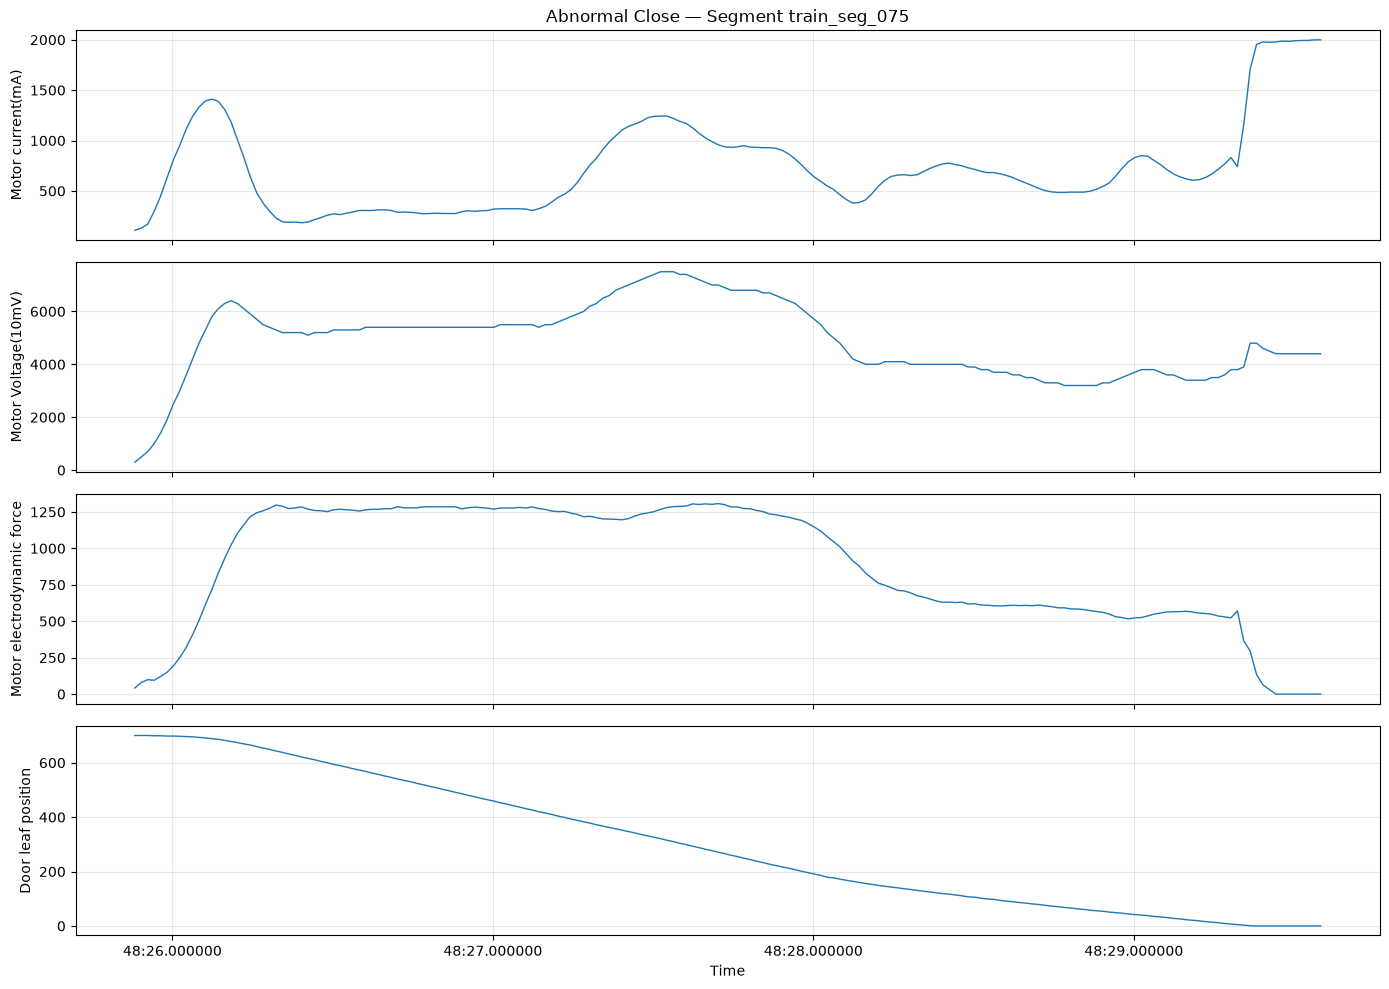

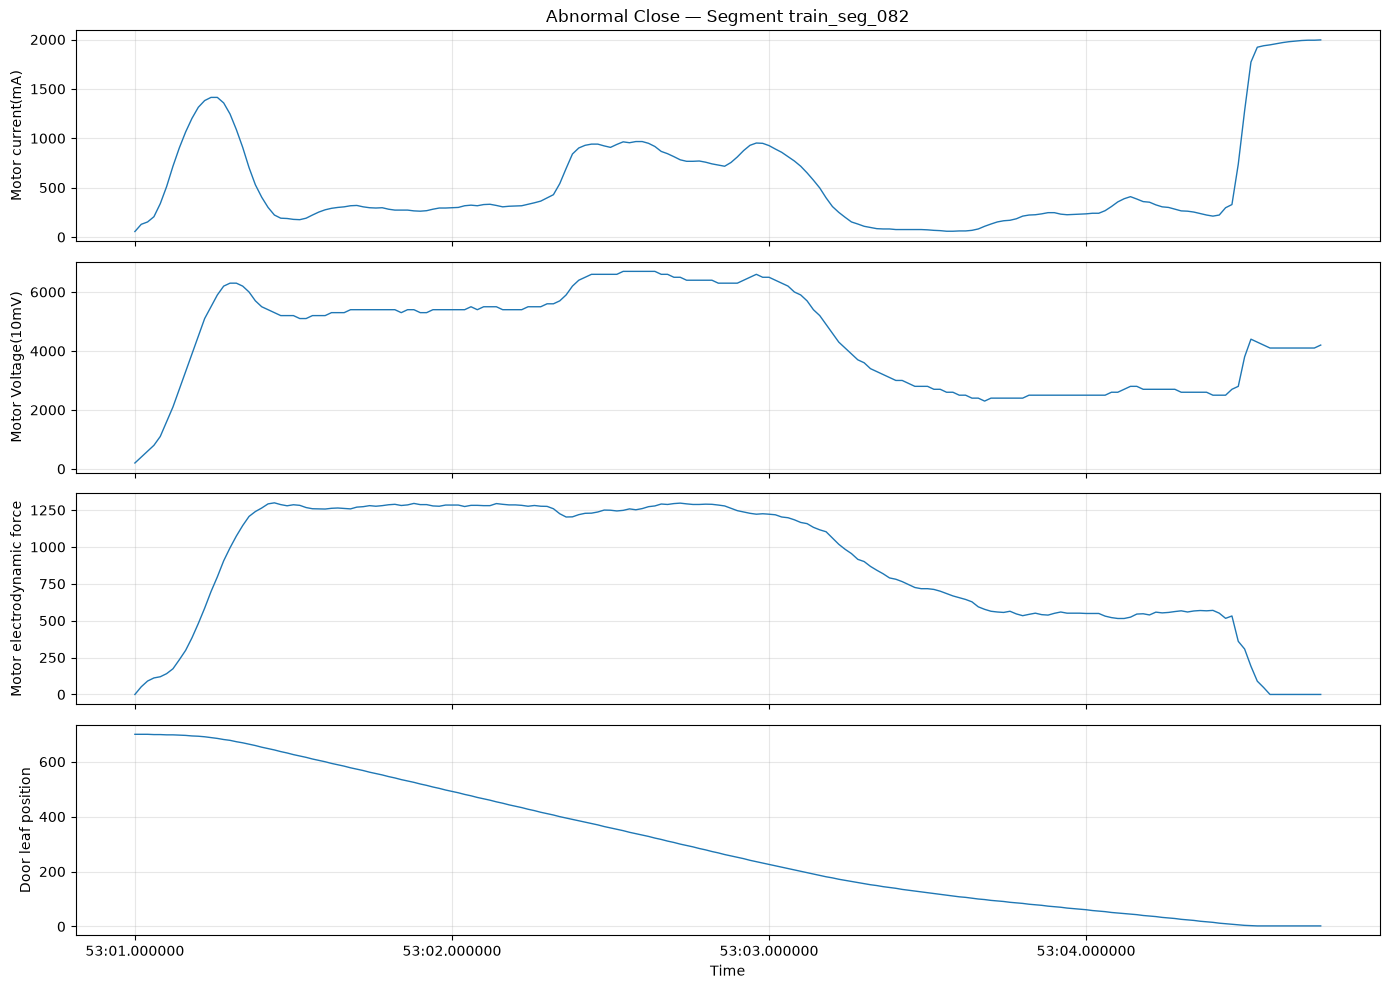

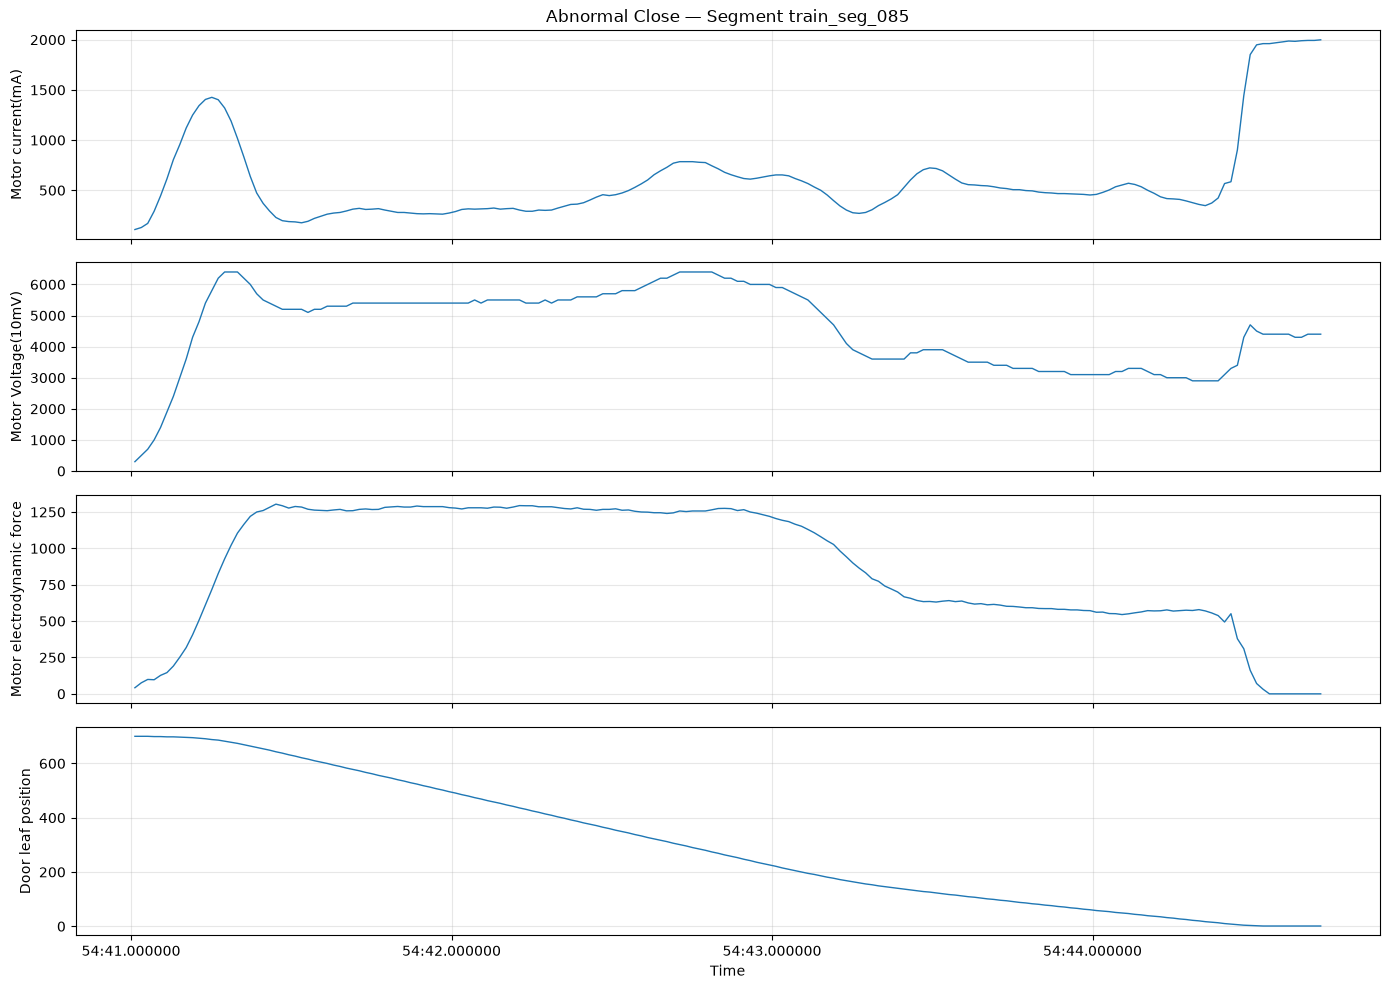

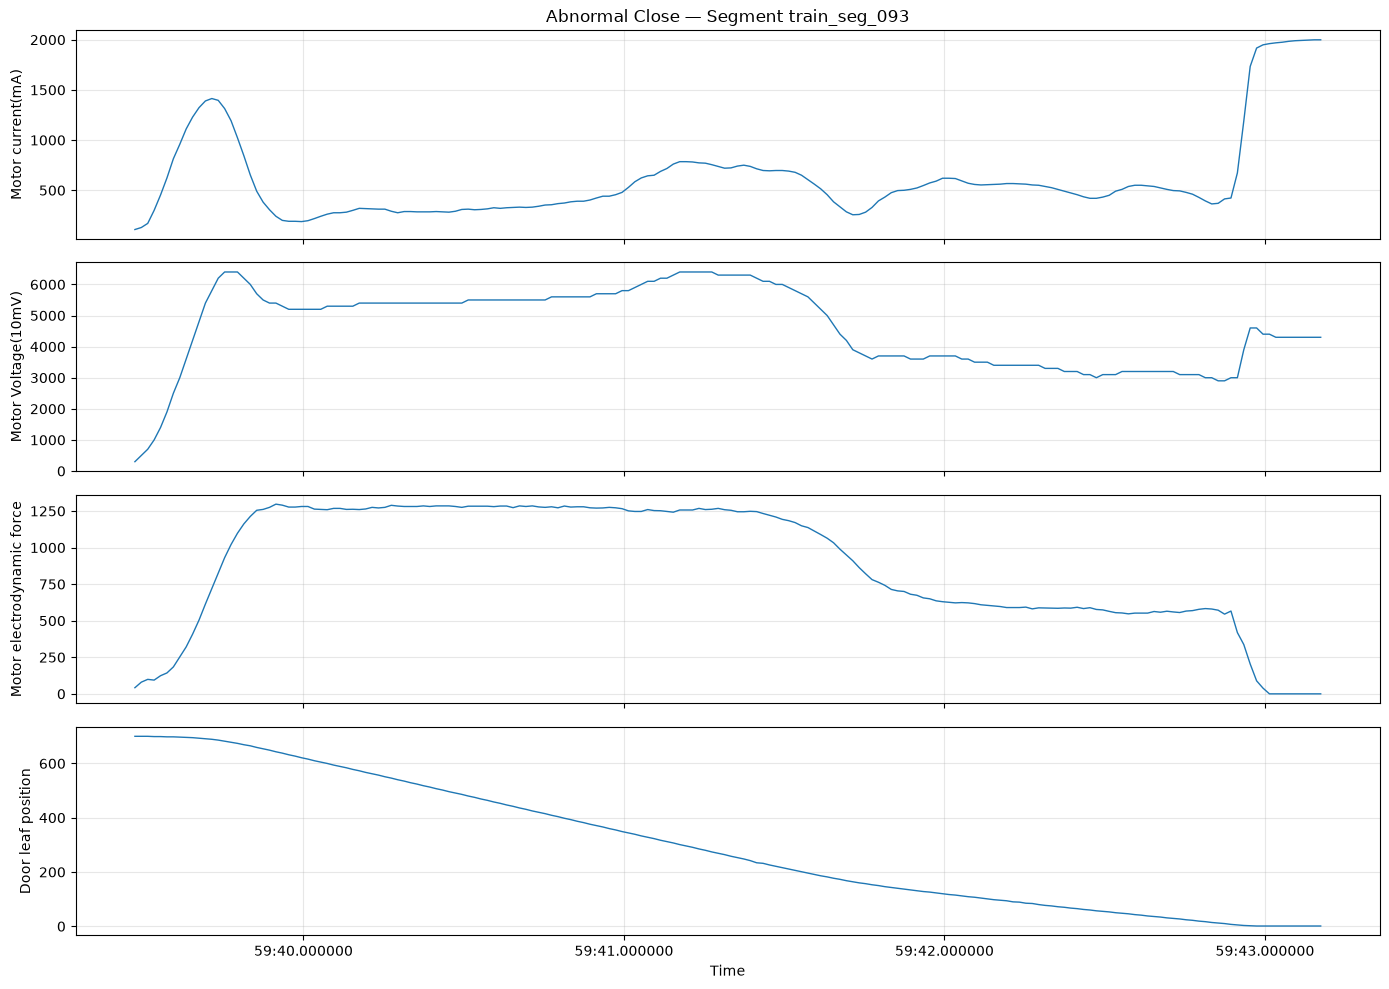

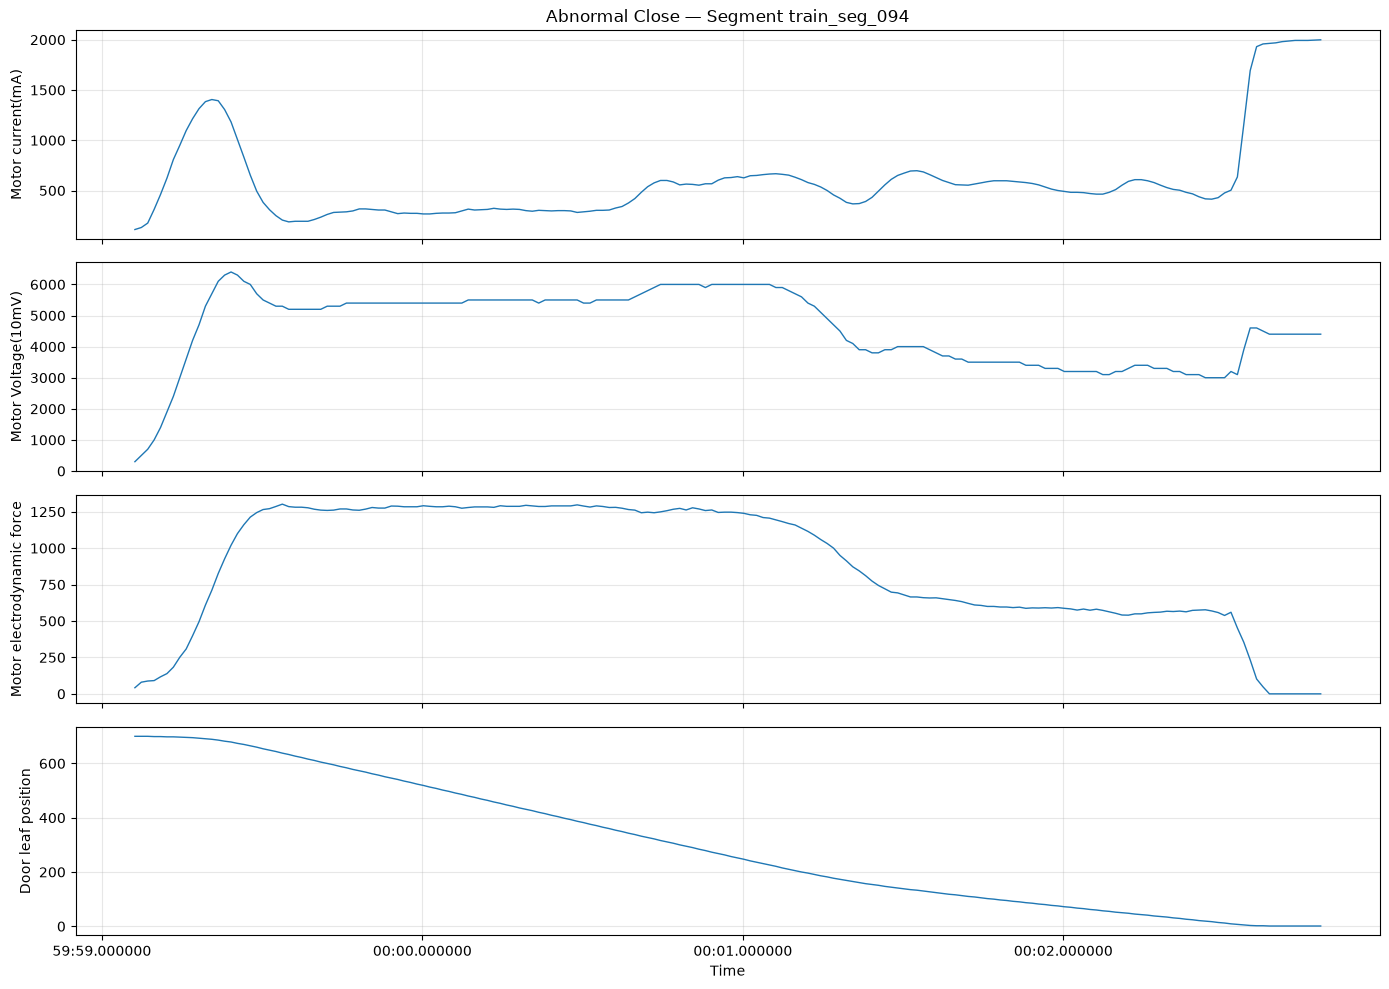

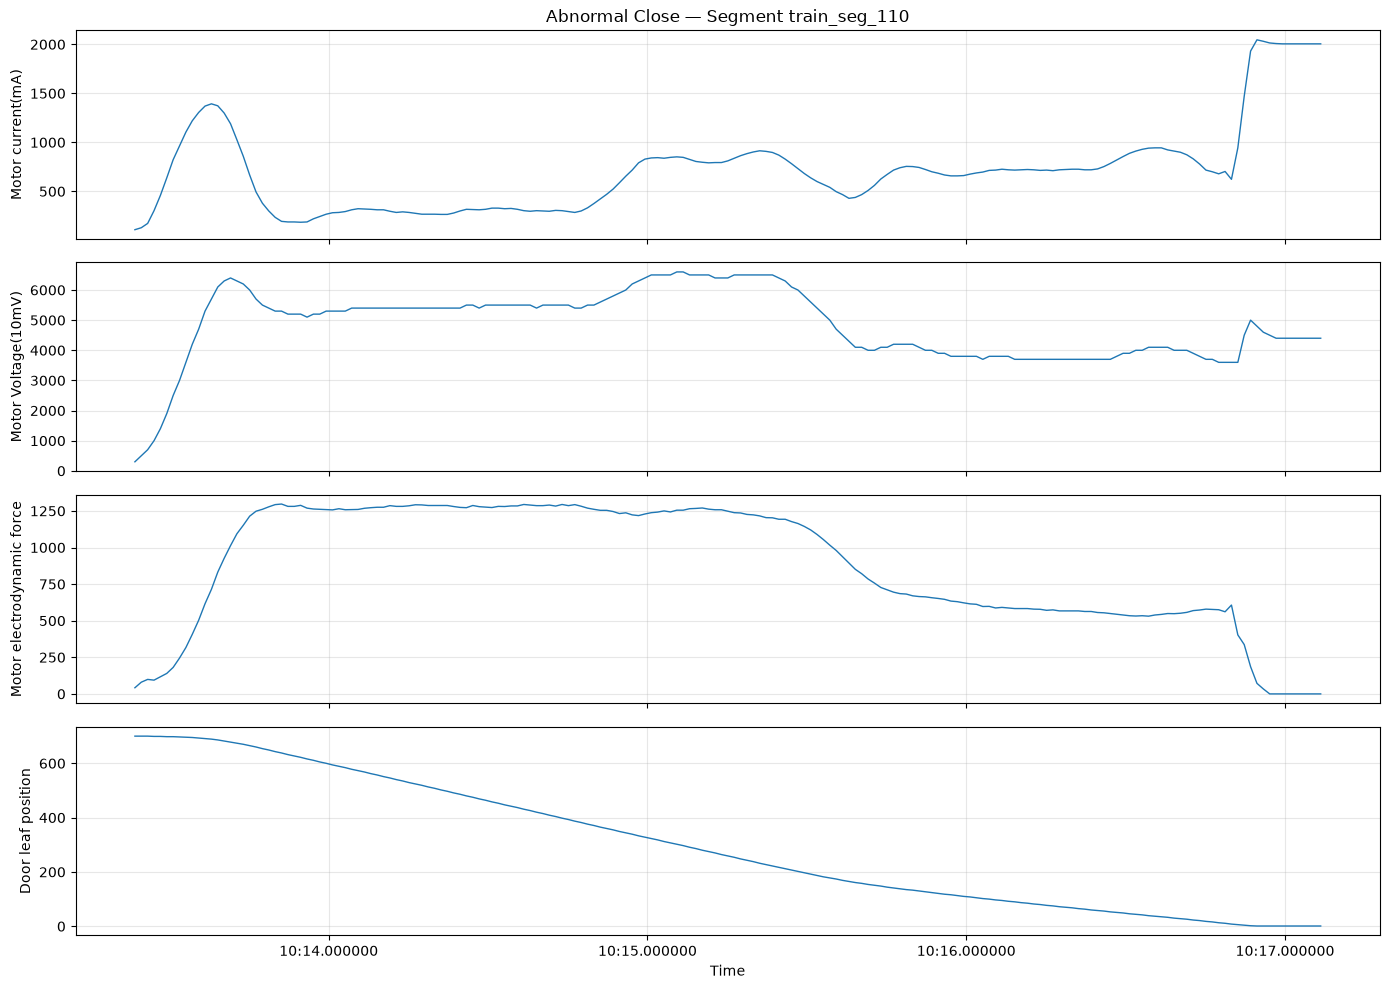

In [26]:
# Plot every abnormal Close cycle separately for the main sensor signals.

for _, segment in abnormal_close.iterrows():
    cycle = extract_cycle(train, segment)

    fig, axes = plt.subplots(len(signals), 1, figsize=(14, 10), sharex=True)

    for ax, signal in zip(axes, signals):
        ax.plot(cycle["timestamp"], cycle[signal], linewidth=1)

        ax.set_ylabel(signal)
        ax.grid(alpha=0.3)

    axes[0].set_title(f"Abnormal Close — Segment {segment['segment_id']}")

    axes[-1].set_xlabel("Time")

    plt.tight_layout()
    plt.show()

In [27]:
# Calculate a simple first difference of door position to approximate movement between samples.


def position_change(cycle):

    position = pd.to_numeric(cycle["Door leaf position"], errors="coerce").to_numpy(dtype=float)

    return np.diff(position)

In [28]:
# Compare the mean absolute position change across Normal and Abnormal Open cycles.

normal_movement = []
abnormal_movement = []

for _, segment in normal_open.iterrows():
    cycle = extract_cycle(train, segment)

    movement = position_change(cycle)

    normal_movement.append(np.mean(np.abs(movement)))

for _, segment in abnormal_open.iterrows():
    cycle = extract_cycle(train, segment)

    movement = position_change(cycle)

    abnormal_movement.append(np.mean(np.abs(movement)))

print("Normal Open mean absolute movement:", np.mean(normal_movement))

print("Abnormal Open mean absolute movement:", np.mean(abnormal_movement))

Normal Open mean absolute movement: 4.962951447183757
Abnormal Open mean absolute movement: 4.964737088198305


In [29]:
# Compare the same movement statistic for Close operations.

normal_movement = []
abnormal_movement = []

for _, segment in normal_close.iterrows():
    cycle = extract_cycle(train, segment)

    movement = position_change(cycle)

    normal_movement.append(np.mean(np.abs(movement)))

for _, segment in abnormal_close.iterrows():
    cycle = extract_cycle(train, segment)

    movement = position_change(cycle)

    abnormal_movement.append(np.mean(np.abs(movement)))

print("Normal Close mean absolute movement:", np.mean(normal_movement))

print("Abnormal Close mean absolute movement:", np.mean(abnormal_movement))

Normal Close mean absolute movement: 3.7946197533917605
Abnormal Close mean absolute movement: 3.7599678316692864


In [30]:
# Calculate a small set of interpretable measurements for every cycle.


def basic_cycle_measurements(cycle):

    measurements = {}

    current = pd.to_numeric(cycle["Motor current(mA)"], errors="coerce").to_numpy(dtype=float)

    voltage = pd.to_numeric(cycle["Motor Voltage(10mV)"], errors="coerce").to_numpy(dtype=float)

    force = pd.to_numeric(cycle["Motor electrodynamic force"], errors="coerce").to_numpy(dtype=float)

    position = pd.to_numeric(cycle["Door leaf position"], errors="coerce").to_numpy(dtype=float)

    measurements["current_mean"] = np.mean(current)
    measurements["current_max"] = np.max(current)
    measurements["current_std"] = np.std(current)

    measurements["voltage_mean"] = np.mean(voltage)
    measurements["voltage_max"] = np.max(voltage)

    measurements["force_mean"] = np.mean(force)
    measurements["force_max"] = np.max(force)

    measurements["position_min"] = np.min(position)
    measurements["position_max"] = np.max(position)
    measurements["position_range"] = np.max(position) - np.min(position)

    measurements["duration_seconds"] = (cycle["timestamp"].iloc[-1] - cycle["timestamp"].iloc[0]).total_seconds()

    return measurements

In [31]:
# Build the measurement table for all 110 labelled operations.

measurement_rows = []

for _, segment in segments.iterrows():
    cycle = extract_cycle(train, segment)

    measurements = basic_cycle_measurements(cycle)

    measurements["segment_id"] = segment["segment_id"]

    measurements["operation"] = segment["operation"]

    measurements["status"] = segment["status"]

    measurement_rows.append(measurements)

measurements_df = pd.DataFrame(measurement_rows)

display(measurements_df.head())

,current_mean,current_max,current_std,voltage_mean,voltage_max,force_mean,force_max,position_min,position_max,position_range,duration_seconds,segment_id,operation,status
0,430.698925,2208.0,523.670601,4146.236559,6200.0,892.069892,1331.0,0.0,700.0,700.0,3.70,train_seg_001,Close,Normal
1,636.265734,2493.0,727.547100,5521.678322,9100.0,1178.727273,2261.0,0.0,701.0,701.0,2.84,train_seg_002,Open,Normal
2,862.452555,2493.0,777.944043,6197.080292,10400.0,1192.430657,2230.0,0.0,695.0,695.0,2.72,train_seg_003,Open,Abnormal resistance
3,576.577540,1993.0,457.693062,4524.598930,6800.0,878.304813,1294.0,0.0,700.0,700.0,3.72,train_seg_004,Close,Abnormal resistance
4,484.548387,1993.0,446.145295,4339.247312,6400.0,881.526882,1298.0,1.0,700.0,699.0,3.70,train_seg_005,Close,Abnormal resistance


In [32]:
# Compare the basic measurements between Normal and Abnormal operations.

measurement_columns = [
    "current_mean",
    "current_max",
    "current_std",
    "voltage_mean",
    "voltage_max",
    "force_mean",
    "force_max",
    "position_range",
    "duration_seconds",
]

display(measurements_df.groupby("status")[measurement_columns].mean())

,current_mean,current_max,current_std,voltage_mean,voltage_max,force_mean,force_max,position_range,duration_seconds
status,,,,,,,,,
Abnormal resistance,719.838916,2255.1000,611.919813,5281.578261,8503.333333,1022.337979,1765.2000,699.70,3.270667
Normal,537.492990,2324.4875,627.601885,4852.658252,7697.500000,1039.654061,1801.8875,699.85,3.255000


In [33]:
# Compare the same measurements separately for Open and Close operations.

for operation in ["Open", "Close"]:
    print(f"\n===== {operation} =====")
    subset = measurements_df[measurements_df["operation"] == operation]
    display(subset.groupby("status")[measurement_columns].mean())


===== Open =====


,current_mean,current_max,current_std,voltage_mean,voltage_max,force_mean,force_max,position_range,duration_seconds
status,,,,,,,,,
Abnormal resistance,824.710651,2503.933333,771.366208,5960.078437,10320.0,1165.300050,2232.800,700.066667,2.821333
Normal,646.901832,2501.150000,736.095869,5562.353139,9177.5,1185.930073,2272.775,699.700000,2.820000



===== Close =====


,current_mean,current_max,current_std,voltage_mean,voltage_max,force_mean,force_max,position_range,duration_seconds
status,,,,,,,,,
Abnormal resistance,614.967180,2006.266667,452.473417,4603.078084,6686.666667,879.375907,1297.6,699.333333,3.72
Normal,428.084149,2147.825000,519.107902,4142.963364,6217.500000,893.378050,1331.0,700.000000,3.69


In [35]:
# Save the simple measurements so they can be reused when comparing future feature sets.

OUTPUT_PATH = Path("fault_analysis_measurements.csv")
measurements_df.to_csv(OUTPUT_PATH, index=False)
print("Saved:", OUTPUT_PATH.resolve())

Saved: /Users/yeo/Documents/Door/NOTEBOOKS/fault_analysis_measurements.csv
